**Healthcare Member Data**

- Contains demographics, risk scores, chronic condition flags, and patient survey responses

<br>

1. Exploratory Data Analysis
2. Text analysis
3. LLM-based topic labelling

In [33]:
!pip install anthropic bertopic sentence-transformers textblob pyLDAvis umap-learn -q

In [34]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, chi2_contingency, f_oneway, kruskal, spearmanr, pearsonr

from textblob import TextBlob
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.manifold import TSNE
from umap import UMAP
from wordcloud import WordCloud
import pyLDAvis
import pyLDAvis.lda_model

from google.colab import drive, userdata
import anthropic


api_key = userdata.get('ANTHROPIC_API_KEY')
client = anthropic.Anthropic(api_key=api_key)

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

Load data

In [35]:
#mount drive
from google.colab import drive
drive.mount('/content/drive')
%cd "/content/drive/MyDrive/Data Science/Projects/Case Study"

file_path = '/content/drive/MyDrive/Data Science/Projects/Case Study/Case Study Data.xlsx'

#load each sheet df
claims_df = pd.read_excel(file_path, sheet_name='Medical claims data')
memsurvey_df = pd.read_excel(file_path, sheet_name='member_data_with_surveys')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Data Science/Projects/Case Study


Helper Functions


In [36]:
def finalize_plot(fig=None, title=""):
    """Apply consistent styling to plots"""
    sns.despine()
    plt.tight_layout()
    if title:
        plt.suptitle(title, fontsize=14, fontweight='bold', y=1.00)
    plt.show()

def print_section(title):
    """Print formatted section header"""
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)

def plot_scatter_by_topic(data, x_col, y_col, title, sample_size=100):
    """Helper function for scatter plots colored by topic"""
    fig, ax = plt.subplots(figsize=(12, 6))

    for topic in data['Topic_Name'].unique():
        if pd.notna(topic):
            topic_data = data[data['Topic_Name'] == topic].sample(
                min(sample_size, len(data[data['Topic_Name'] == topic]))
            )
            ax.scatter(topic_data[x_col], topic_data[y_col], label=topic, alpha=0.6, s=40)

    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(title)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)
    finalize_plot()

**Preview and Quality Checks**

In [37]:
print("Medical Claims data: ")
print(claims_df.shape)
print(claims_df.head())
print(claims_df.dtypes)
print(claims_df.describe())

Medical Claims data: 
(144247, 18)
   Member ID              Claim Number Service Date  Paid Date  \
0        1.0  H19343218281891900000000   2019-11-13 2019-12-13   
1        1.0  H19343218281891900000000   2019-11-13 2019-12-13   
2        1.0  H19324218270523690000000   2019-11-13 2019-11-22   
3        1.0  H19323218269729840000000   2019-11-15 2019-11-22   
4        1.0  H19343218281960710000000   2019-11-13 2019-12-13   

  Place of Service Description Speciality Provider Specialty  Paid Amount  \
0          Outpatient Hospital         A1           DWSC1-12   159.377500   
1          Outpatient Hospital         A1           DWSC1-12    14.223654   
2           Inpatient Hospital         A1           DWSC1-12    56.709615   
3           Inpatient Hospital         AW            DWSC1-3    45.346346   
4    Emergency Room - Hospital         CS           DWSC1-12   186.280769   

   Allowed Amount Primary Diagnosis Desc       Procedure Description   CPT4  \
0      159.377500     Edem

In [38]:
print("Member data with surveys:")
print(memsurvey_df.shape)
print(memsurvey_df.head())
print(memsurvey_df.dtypes)
print(memsurvey_df.describe())

Member data with surveys:
(4783, 22)
   Member ID  Age Member Gender Prospective Risk Concurrent Risk  \
0          1   84             F            23.72           13.39   
1          2   62             F             1.76            0.75   
2          3   73             F             0.85            0.42   
3          4   44             M             0.82            0.36   
4          5   44             F             0.13               0   

   # of Chronic Conditions ADHD Asthma Blood Disorders Cancer Chronic Pain  \
0                        7   No     No              No    Yes           No   
1                        4   No     No              No     No          Yes   
2                        2   No     No              No     No           No   
3                        3   No     No              No     No           No   
4                        0   No     No              No     No           No   

  Congestive Heart Failure Chronic Respiratory Failure Depression Diabetes  \
0      

In [39]:
missing_percent = (claims_df.isnull().sum() / len(claims_df) * 100).round(2)
print('Missing values %:')
print(missing_percent[missing_percent > 0].sort_values(ascending=False))
print(claims_df.isnull().sum())

missing_percent = (memsurvey_df.isnull().sum() / len(memsurvey_df) * 100).round(2)
print('Missing values %:')
print(missing_percent[missing_percent > 0].sort_values(ascending=False))
print(memsurvey_df.isnull().sum())

Missing values %:
Series([], dtype: float64)
Member ID                         0
Claim Number                      0
Service Date                      0
Paid Date                         0
Place of Service Description      0
Speciality                        0
Provider Specialty                0
Paid Amount                       0
Allowed Amount                    0
Primary Diagnosis Desc            0
Procedure Description             0
CPT4                              0
Vendor Name                       0
Procedure                         0
Procedure Grouper Desc            0
Procedure Sub-Grouper Desc        0
Diagnosis Grouper 1 Desc          0
Diagnosis Super-Grouper 1 Desc    0
dtype: int64
Missing values %:
Patient Survey Response    14.99
dtype: float64
Member ID                        0
Age                              0
Member Gender                    0
Prospective Risk                 0
Concurrent Risk                  0
# of Chronic Conditions          0
ADHD              

**Data Cleaning**

In [40]:
#clean member ids in claims data
claims_df = claims_df[claims_df['Member ID'] % 1 == 0].copy()
claims_df['Member ID'] = claims_df['Member ID'].astype('int64')


#aggregate claims data by member
claims_summary = claims_df.groupby('Member ID').agg({
    'Paid Amount': 'sum',
    'Claim Number': 'count'
}).reset_index()

claims_summary.columns = ['Member ID', 'Total Paid Amount', 'Claim Count']
print(claims_summary.head())

#merge with member data
merged_df = memsurvey_df.merge(claims_summary, on='Member ID', how='left')

print(f"\nMerged data shape: {merged_df.shape}")
print(f"Duplicate Member IDs: {merged_df['Member ID'].duplicated().sum()}")
print(f"Members with surveys: {merged_df['Patient Survey Response'].notna().sum()} / {len(merged_df)}")
print(f"Members with claims: {merged_df['Total Paid Amount'].notna().sum()} / {len(merged_df)}")
print(f"Negative costs: {(merged_df['Total Paid Amount'] < 0).sum()}")

#convert risk scores to numeric
merged_df['Prospective Risk'] = pd.to_numeric(merged_df['Prospective Risk'], errors='coerce')
merged_df['Concurrent Risk'] = pd.to_numeric(merged_df['Concurrent Risk'], errors='coerce')
print(merged_df[['Prospective Risk', 'Concurrent Risk']].head())

#create response flag
merged_df['Responded'] = merged_df['Patient Survey Response'].notna().astype(int)
print(merged_df['Responded'].value_counts())
print(merged_df[['Patient Survey Response', 'Responded']].head(10))


   Member ID  Total Paid Amount  Claim Count
0          1       45225.534038          207
1          2        1242.260769           16
2          3         880.443462           28
3          4         635.453654            9
4          5         127.116346            2

Merged data shape: (4783, 24)
Duplicate Member IDs: 0
Members with surveys: 4066 / 4783
Members with claims: 3499 / 4783
Negative costs: 2
   Prospective Risk  Concurrent Risk
0             23.72            13.39
1              1.76             0.75
2              0.85             0.42
3              0.82             0.36
4              0.13             0.00
Responded
1    4066
0     717
Name: count, dtype: int64
                             Patient Survey Response  Responded
0                                                NaN          0
1  I don't feel like my doctor listens to my conc...          1
2  My provider is knowledgeable and compassionate...          1
3  My provider is knowledgeable and compassionate...    

**1. Exploratory Data Analysis**

<Figure size 600x250 with 0 Axes>

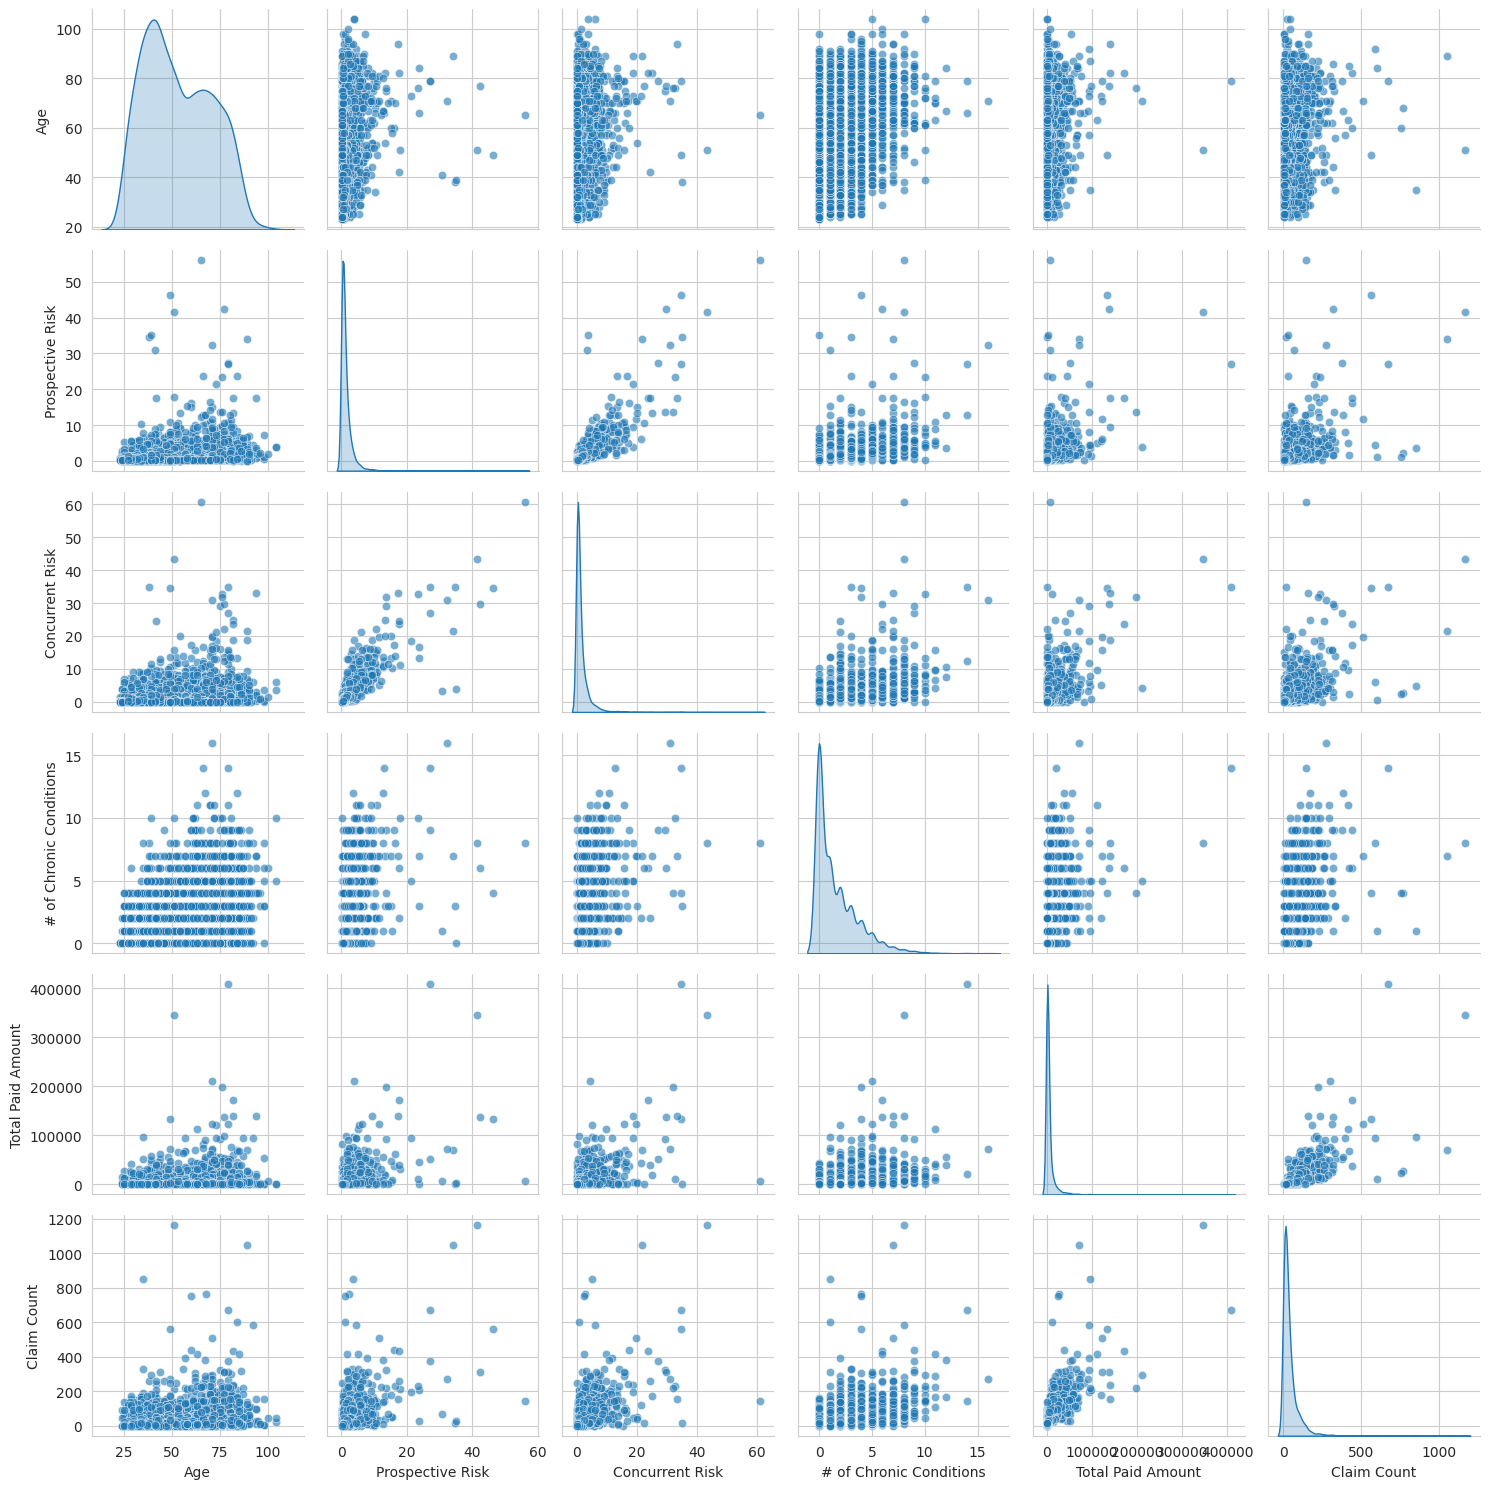

In [41]:
fig = plt.figure(figsize=(6, 2.5))
sns.pairplot(data=merged_df[['Age', 'Prospective Risk', 'Concurrent Risk', '# of Chronic Conditions', 'Total Paid Amount', 'Claim Count']],
             diag_kind='kde', plot_kws={'alpha': 0.6}, diag_kws={'shade': True})
finalize_plot()

Notes:
- Member ID: uniformly distributed
- Age: normal-ish, centered around 50-60
- number of chronic conditions: heavy right skew, most have 0-5, few have 10+
- Total paid amount: heavy right skew, most people cost %0-50k, a few >$300k
- Claim count: right skew, most members have few claims, some have 1000+

<br><br>
Key patterns:
- Age alone doesn't predict costs
- More chronic conditions means more total paid amount
- More claims means more total paid amount


In [42]:
#convert conditions to binary
conditions = ['ADHD', 'Asthma',
       'Blood Disorders', 'Cancer', 'Chronic Pain', 'Congestive Heart Failure',
       'Chronic Respiratory Failure', 'Depression', 'Diabetes', 'ESRD',
       'Eating Disorders', 'HIV/AIDS', 'Hyperlipidemia', 'Hypertension',
       'Lower Back Pain',]

for col in conditions:
    merged_df[col] = (merged_df[col] == 'Yes').astype(int)

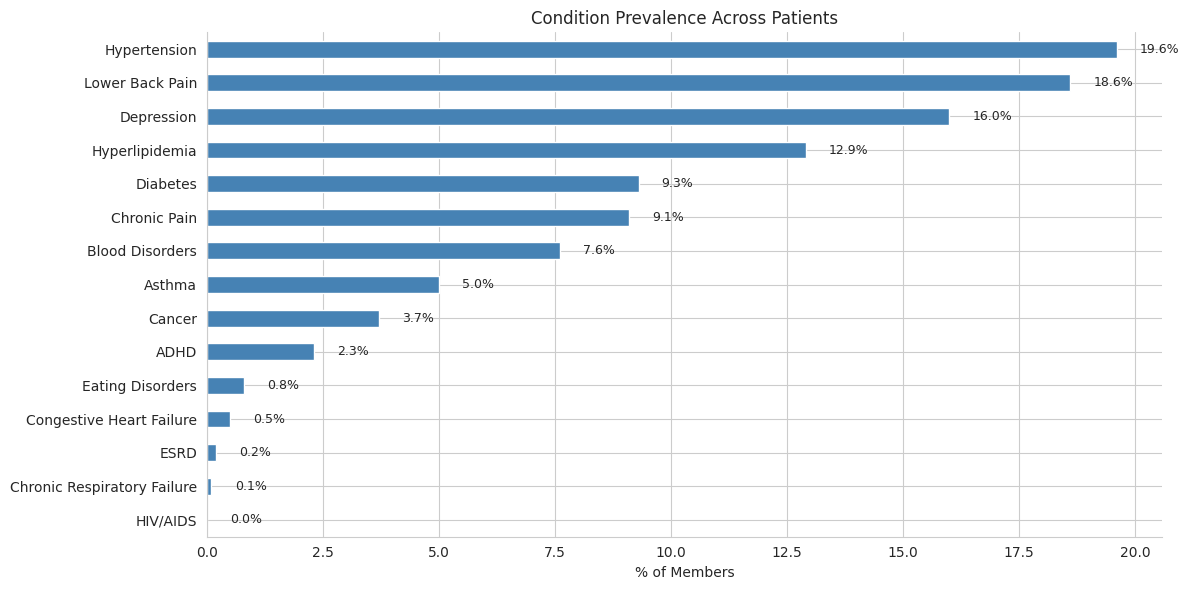

In [43]:
prevalence = merged_df[conditions].sum().sort_values(ascending=True)
prevalence_pct = (prevalence / len(merged_df) * 100).round(1)

plt.figure(figsize=(12, 6))
ax = prevalence_pct.plot(kind='barh', color='steelblue')
ax.set_xlabel('% of Members')
ax.set_title('Condition Prevalence Across Patients')

#percentage labels
for i, v in enumerate(prevalence_pct):
    ax.text(v + 0.5, i, f'{v}%', va='center', fontsize=9)

finalize_plot()

Most common conidtions include hypertension, lower back pain, depression.

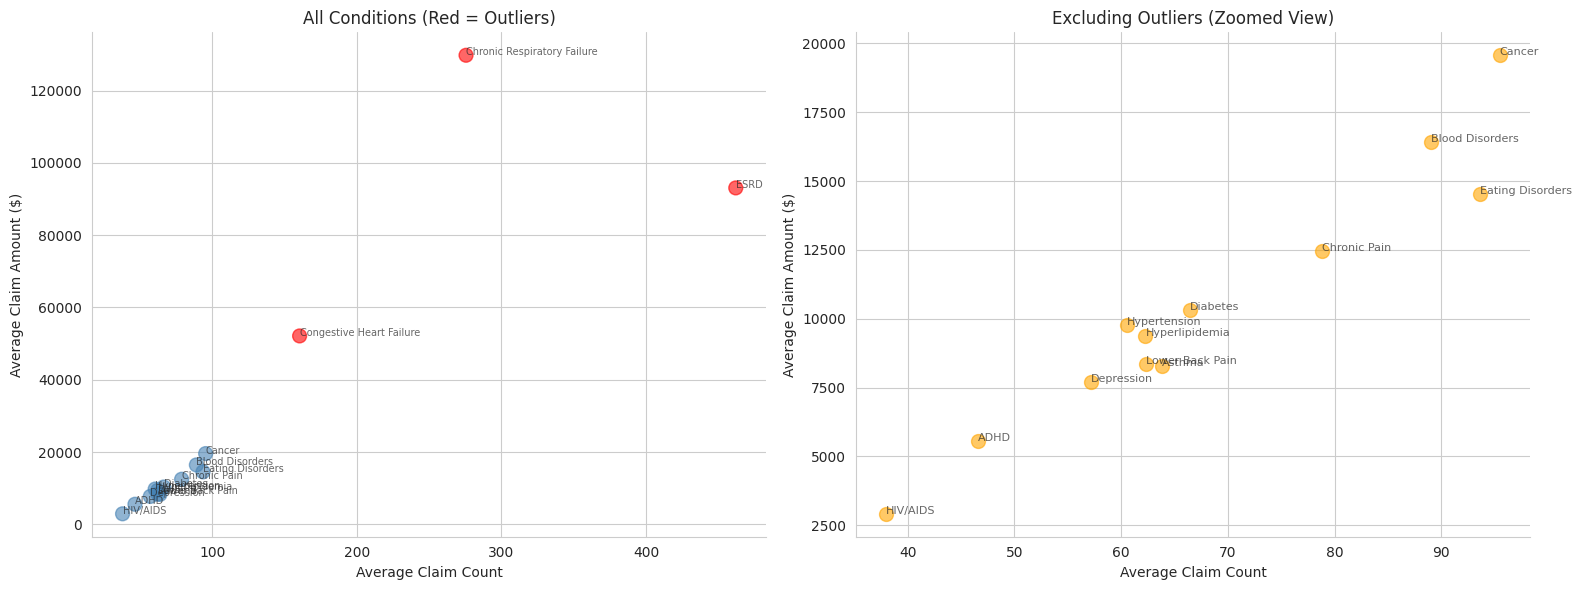

In [44]:
#condition-level aggregation
condition_claims = []
for condition in conditions:
    cond_members = merged_df[merged_df[condition] == 1]
    condition_claims.append({
        'Condition': condition,
        'Avg_Claim_Count': cond_members['Claim Count'].mean(),
        'Avg_Claim_Amount': cond_members['Total Paid Amount'].mean(),
        'Member_Count': len(cond_members)
    })

condition_df = pd.DataFrame(condition_claims).sort_values('Avg_Claim_Amount', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

#full chart outliers highlighted
outliers = ['Chronic Respiratory Failure', 'ESRD', 'Congestive Heart Failure']
colors = ['red' if cond in outliers else 'steelblue' for cond in condition_df['Condition']]

ax1.scatter(condition_df['Avg_Claim_Count'], condition_df['Avg_Claim_Amount'],
           s=100, alpha=0.6, c=colors)
ax1.set_xlabel('Average Claim Count')
ax1.set_ylabel('Average Claim Amount ($)')
ax1.set_title('All Conditions (Red = Outliers)')

for i, cond in enumerate(condition_df['Condition']):
    ax1.annotate(cond, (condition_df['Avg_Claim_Count'].iloc[i],
                        condition_df['Avg_Claim_Amount'].iloc[i]),
                fontsize=7, alpha=0.7)

#zoomed in, excluding outliers
condition_df_zoomed = condition_df[~condition_df['Condition'].isin(outliers)]
ax2.scatter(condition_df_zoomed['Avg_Claim_Count'], condition_df_zoomed['Avg_Claim_Amount'],
           s=100, alpha=0.6, color='orange')
ax2.set_xlabel('Average Claim Count')
ax2.set_ylabel('Average Claim Amount ($)')
ax2.set_title('Excluding Outliers (Zoomed View)')

for i, cond in enumerate(condition_df_zoomed['Condition']):
    ax2.annotate(cond, (condition_df_zoomed['Avg_Claim_Count'].iloc[i],
                        condition_df_zoomed['Avg_Claim_Amount'].iloc[i]),
                fontsize=8, alpha=0.7)

finalize_plot()

In [45]:
#age significance, members with vs. without conditions
age_analysis = []
for condition in conditions:
    has_cond_age = merged_df[merged_df[condition] == 1]['Age']
    no_cond_age = merged_df[merged_df[condition] == 0]['Age']

    t_stat, p_value = ttest_ind(has_cond_age, no_cond_age)

    age_analysis.append({
        'Condition': condition,
        'With_Condition_Age': has_cond_age.mean(),
        'Without_Condition_Age': no_cond_age.mean(),
        'Age_Difference': has_cond_age.mean() - no_cond_age.mean(),
        'P_Value': p_value,
        'Significant': '***' if p_value < 0.05 else ''
    })

age_df = pd.DataFrame(age_analysis).sort_values('Age_Difference', ascending=False)
print("\n" + age_df.to_string())


                      Condition  With_Condition_Age  Without_Condition_Age  Age_Difference        P_Value Significant
5      Congestive Heart Failure           72.038462              53.088922       18.949540   2.877497e-08         ***
12               Hyperlipidemia           69.585366              50.773033       18.812333  3.755644e-148         ***
13                 Hypertension           68.172009              49.547180       18.624829  5.130474e-209         ***
9                          ESRD           71.500000              53.161257       18.338743   2.874121e-03         ***
6   Chronic Respiratory Failure           71.142857              53.165620       17.977237   6.266796e-03         ***
3                        Cancer           69.533708              52.560261       16.973447   5.439424e-38         ***
8                      Diabetes           64.943820              51.986399       12.957421   8.150417e-52         ***
2               Blood Disorders           59.879121    

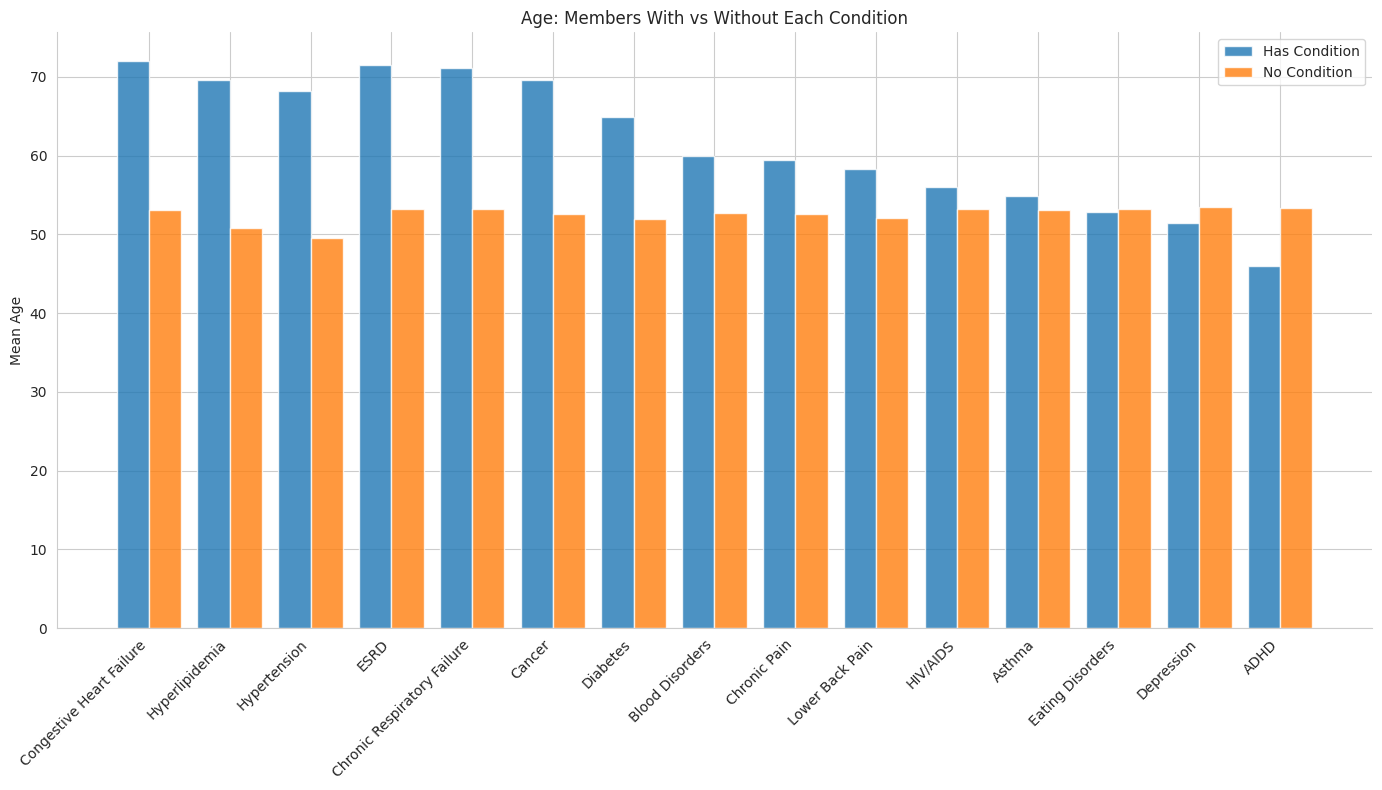

In [46]:
fig, ax = plt.subplots(figsize=(14, 8))
x = np.arange(len(age_df))
ax.bar(x - 0.2, age_df['With_Condition_Age'], 0.4, label='Has Condition', alpha=0.8)
ax.bar(x + 0.2, age_df['Without_Condition_Age'], 0.4, label='No Condition', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(age_df['Condition'], rotation=45, ha='right')
ax.set_ylabel('Mean Age')
ax.set_title('Age: Members With vs Without Each Condition')
ax.legend()
finalize_plot()

12 conditions show significant differences in age

                  Condition  Mean_Age_With  Mean_Age_Without  Age_Diff       P_Value Significant
   Congestive Heart Failure      72.038462         53.088922 18.949540  2.877497e-08         Yes
             Hyperlipidemia      69.585366         50.773033 18.812333 3.755644e-148         Yes
               Hypertension      68.172009         49.547180 18.624829 5.130474e-209         Yes
                       ESRD      71.500000         53.161257 18.338743  2.874121e-03         Yes
Chronic Respiratory Failure      71.142857         53.165620 17.977237  6.266796e-03         Yes
                     Cancer      69.533708         52.560261 16.973447  5.439424e-38         Yes
                   Diabetes      64.943820         51.986399 12.957421  8.150417e-52         Yes
            Blood Disorders      59.879121         52.641095  7.238026  1.943806e-14         Yes
               Chronic Pain      59.425287         52.568307  6.856980  3.707201e-15         Yes
            Lower Back Pain   

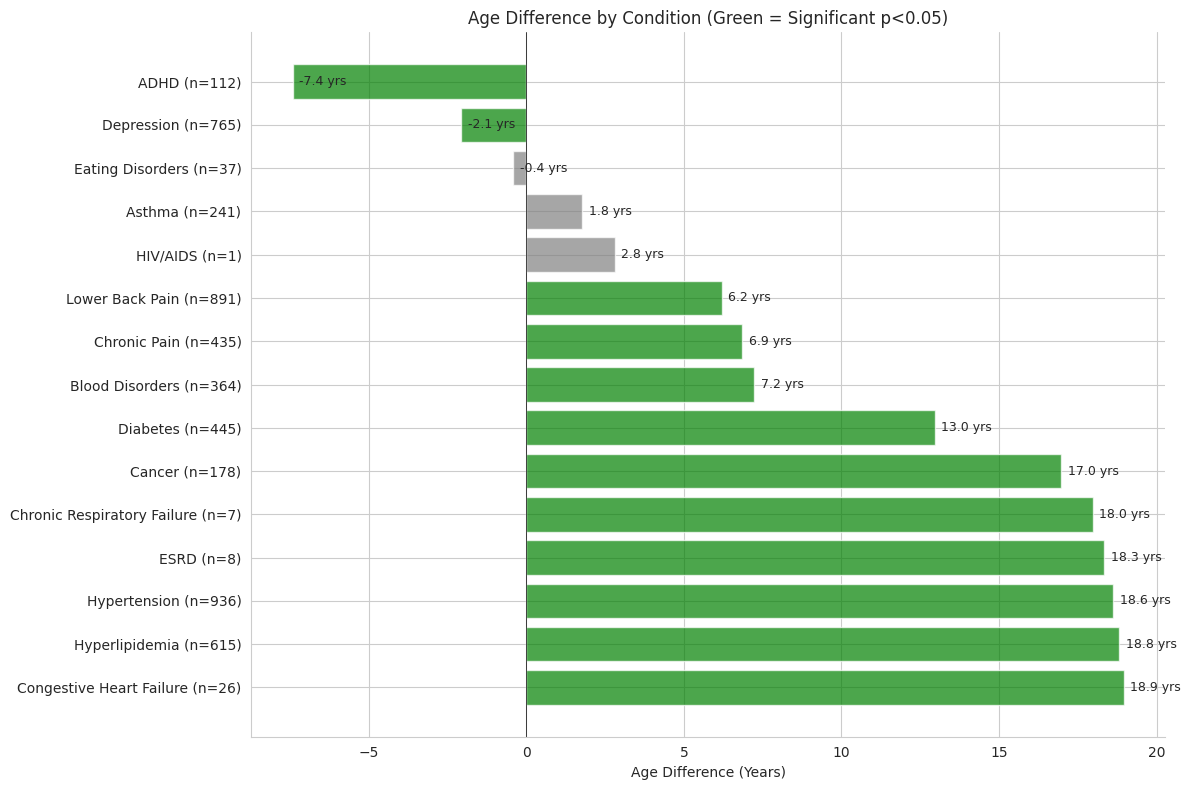

In [47]:

results = []
for condition in conditions:
    has = merged_df[merged_df[condition] == 1]['Age']
    no = merged_df[merged_df[condition] == 0]['Age']
    t_stat, p_val = ttest_ind(has, no)

    results.append({
        'Condition': condition,
        'Mean_Age_With': has.mean(),
        'Mean_Age_Without': no.mean(),
        'Age_Diff': has.mean() - no.mean(),
        'P_Value': p_val,
        'N_With': len(has),
        'Significant': 'Yes' if p_val < 0.05 else 'No'
    })

sig_df = pd.DataFrame(results).sort_values('Age_Diff', ascending=False)
print(sig_df[['Condition', 'Mean_Age_With', 'Mean_Age_Without', 'Age_Diff', 'P_Value', 'Significant']].to_string(index=False))

#plot
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['green' if p < 0.05 else 'gray' for p in sig_df['P_Value']]

ax.barh(sig_df['Condition'] + ' (n=' + sig_df['N_With'].astype(str) + ')', sig_df['Age_Diff'], color=colors, alpha=0.7)
ax.set_xlabel('Age Difference (Years)')
ax.set_title('Age Difference by Condition (Green = Significant p<0.05)')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

for i, diff in enumerate(sig_df['Age_Diff']):
    ax.text(diff + 0.2, i, f'{diff:.1f} yrs', va='center', fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()

Are older members more likely to have each condition?


**Survey Engagement: Responders vs. Non-Responders**

In [48]:
engagement_results = []

for condition in conditions:
    has_cond = merged_df[merged_df[condition] == 1]

    responders = has_cond[has_cond['Responded'] == 1]
    non_responders = has_cond[has_cond['Responded'] == 0]

    engagement_results.append({
        'Condition': condition,
        'Responders_Count': len(responders),
        'Non_Responders_Count': len(non_responders),
        'Response_Rate_%': round(len(responders) / len(has_cond) * 100, 2),
        'Responders_Avg_Cost': responders['Total Paid Amount'].mean(),
        'Non_Responders_Avg_Cost': non_responders['Total Paid Amount'].mean(),
        'Cost_Difference': responders['Total Paid Amount'].mean() - non_responders['Total Paid Amount'].mean(),
        'Responders_Avg_ClaimCount': responders['Claim Count'].mean(),
        'Non_Responders_Avg_ClaimCount': non_responders['Claim Count'].mean()
    })

engagement_df = pd.DataFrame(engagement_results).sort_values('Response_Rate_%', ascending=False)

print(engagement_df[['Condition', 'Response_Rate_%', 'Responders_Count', 'Non_Responders_Count',
                     'Responders_Avg_Cost', 'Non_Responders_Avg_Cost', 'Cost_Difference']].to_string(index=False))

                  Condition  Response_Rate_%  Responders_Count  Non_Responders_Count  Responders_Avg_Cost  Non_Responders_Avg_Cost  Cost_Difference
                       ESRD           100.00                 8                     0         93078.592837                      NaN              NaN
                   HIV/AIDS           100.00                 1                     0          2913.899423                      NaN              NaN
           Eating Disorders            94.59                35                     2         15004.993994              7291.501058      7713.492936
                     Asthma            86.72               209                    32          9009.931995              3359.086711      5650.845284
               Chronic Pain            86.44               376                    59         12586.005673             11782.194241       803.811432
Chronic Respiratory Failure            85.71                 6                     1        155655.234538       

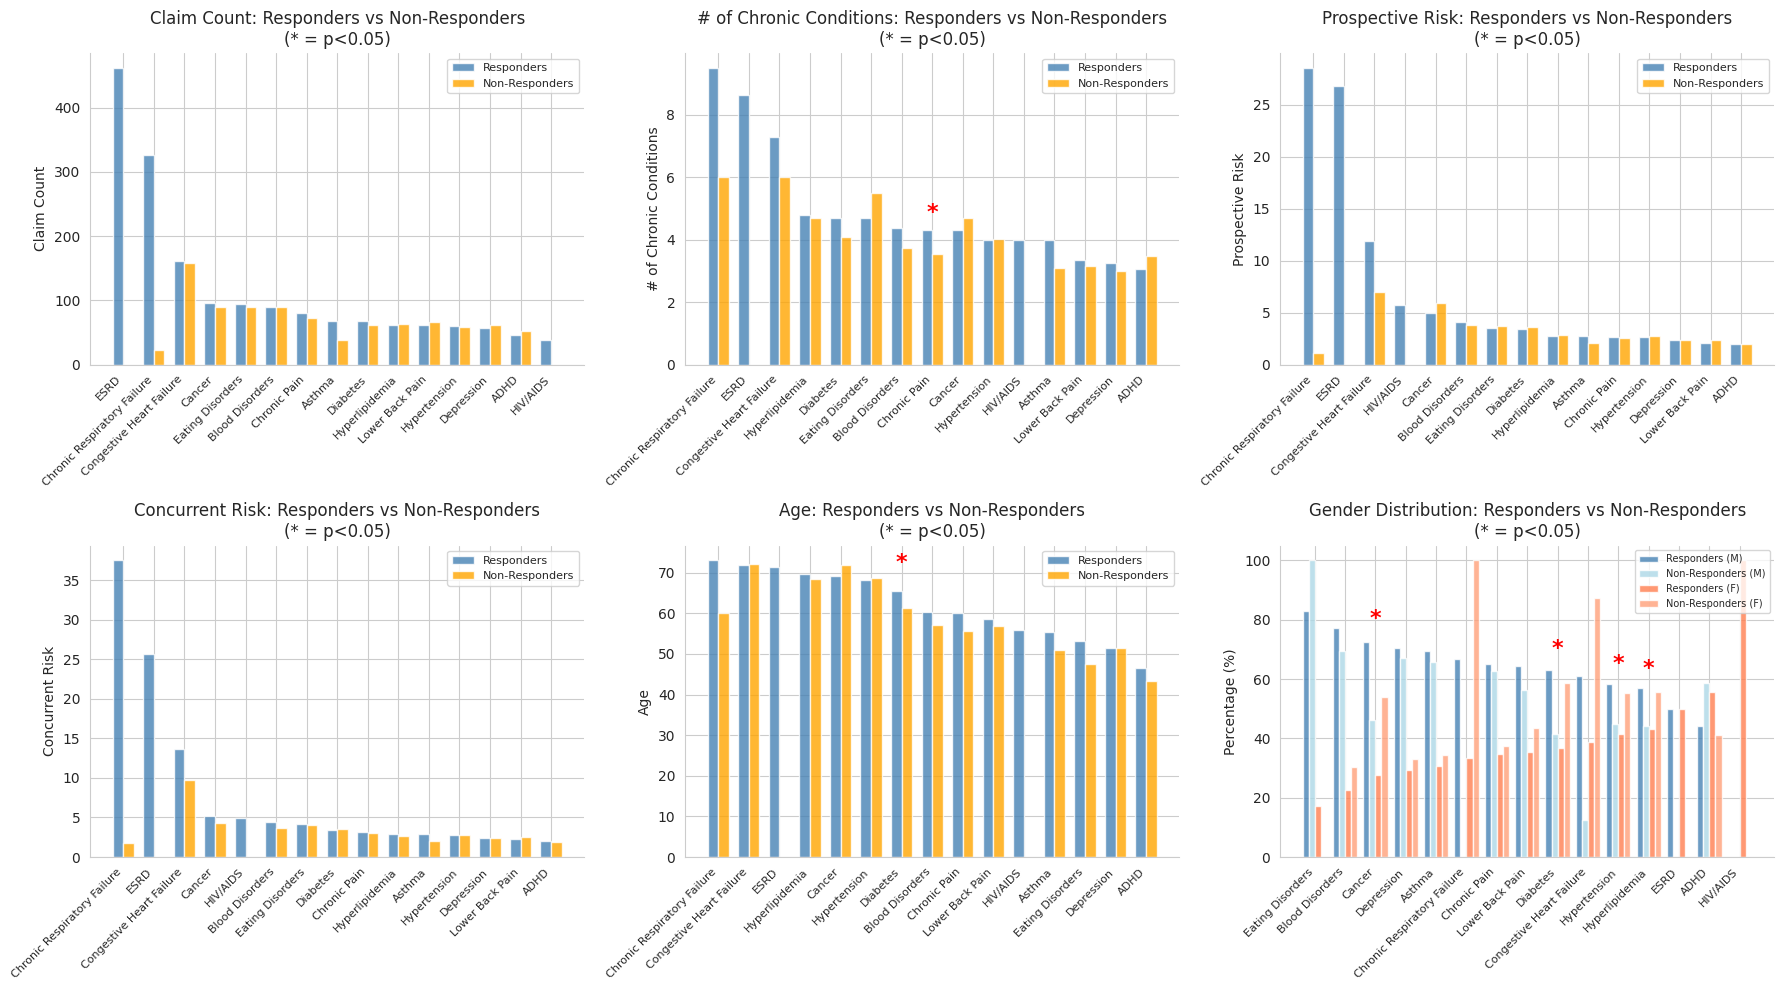

In [49]:
from scipy.stats import ttest_ind, chi2_contingency

metrics = ['Claim Count', '# of Chronic Conditions', 'Prospective Risk', 'Concurrent Risk', 'Age']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    # Run significance tests
    metric_data = []

    for condition in conditions:
        resp_data = merged_df[(merged_df[condition] == 1) & (merged_df['Responded'] == 1)][metric].dropna()
        non_resp_data = merged_df[(merged_df[condition] == 1) & (merged_df['Responded'] == 0)][metric].dropna()

        if len(resp_data) > 1 and len(non_resp_data) > 1:
            t_stat, p_val = ttest_ind(resp_data, non_resp_data)
            resp_mean = resp_data.mean()
            non_resp_mean = non_resp_data.mean()
        else:
            p_val = 1.0
            resp_mean = resp_data.mean() if len(resp_data) > 0 else 0
            non_resp_mean = non_resp_data.mean() if len(non_resp_data) > 0 else 0

        metric_data.append({
            'Condition': condition,
            'Responders_Mean': resp_mean,
            'Non_Responders_Mean': non_resp_mean,
            'P_Value': p_val,
            'Significant': p_val < 0.05
        })

    metric_df = pd.DataFrame(metric_data).sort_values('Responders_Mean', ascending=False)

    # Create chart
    ax = axes[idx]
    x = np.arange(len(metric_df))
    width = 0.35

    ax.bar(x - width/2, metric_df['Responders_Mean'], width, label='Responders', alpha=0.8, color='steelblue')
    ax.bar(x + width/2, metric_df['Non_Responders_Mean'], width, label='Non-Responders', alpha=0.8, color='orange')

    # Add significance stars
    for i, (resp, non_resp, sig) in enumerate(zip(metric_df['Responders_Mean'],
                                                    metric_df['Non_Responders_Mean'],
                                                    metric_df['Significant'])):
        if sig:
            max_val = max(resp, non_resp)
            ax.text(i, max_val * 1.08, '*', ha='center', fontsize=16, fontweight='bold', color='red')

    ax.set_xticks(x)
    ax.set_xticklabels(metric_df['Condition'], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel(metric)
    ax.set_title(f'{metric}: Responders vs Non-Responders\n(* = p<0.05)')
    ax.legend(fontsize=8)

# Gender breakdown - Male vs Female
gender_data = []
for condition in conditions:
    resp_gender = merged_df[(merged_df[condition] == 1) & (merged_df['Responded'] == 1)]['Member Gender']
    non_resp_gender = merged_df[(merged_df[condition] == 1) & (merged_df['Responded'] == 0)]['Member Gender']

    if len(resp_gender) > 0 and len(non_resp_gender) > 0:
        contingency = pd.crosstab(
            pd.Series(['Responder']*len(resp_gender) + ['Non-Responder']*len(non_resp_gender)),
            pd.Series(list(resp_gender) + list(non_resp_gender))
        )
        chi2, p_val, dof, expected = chi2_contingency(contingency)
    else:
        p_val = 1.0

    gender_data.append({
        'Condition': condition,
        'Responder_M_%': (resp_gender == 'M').sum() / len(resp_gender) * 100 if len(resp_gender) > 0 else 0,
        'Non_Responder_M_%': (non_resp_gender == 'M').sum() / len(non_resp_gender) * 100 if len(non_resp_gender) > 0 else 0,
        'Responder_F_%': (resp_gender == 'F').sum() / len(resp_gender) * 100 if len(resp_gender) > 0 else 0,
        'Non_Responder_F_%': (non_resp_gender == 'F').sum() / len(non_resp_gender) * 100 if len(non_resp_gender) > 0 else 0,
        'P_Value': p_val,
        'Significant': p_val < 0.05
    })

gender_df = pd.DataFrame(gender_data).sort_values('Responder_M_%', ascending=False)

ax = axes[5]
x = np.arange(len(gender_df))
width = 0.2

ax.bar(x - 1.5*width, gender_df['Responder_M_%'], width, label='Responders (M)', alpha=0.8, color='steelblue')
ax.bar(x - 0.5*width, gender_df['Non_Responder_M_%'], width, label='Non-Responders (M)', alpha=0.8, color='lightblue')
ax.bar(x + 0.5*width, gender_df['Responder_F_%'], width, label='Responders (F)', alpha=0.8, color='coral')
ax.bar(x + 1.5*width, gender_df['Non_Responder_F_%'], width, label='Non-Responders (F)', alpha=0.8, color='lightsalmon')

# Add significance stars
for i, sig in enumerate(gender_df['Significant']):
    if sig:
        max_val = max(gender_df['Responder_M_%'].iloc[i], gender_df['Non_Responder_M_%'].iloc[i],
                     gender_df['Responder_F_%'].iloc[i], gender_df['Non_Responder_F_%'].iloc[i])
        ax.text(i, max_val * 1.08, '*', ha='center', fontsize=16, fontweight='bold', color='red')

ax.set_xticks(x)
ax.set_xticklabels(gender_df['Condition'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Percentage (%)')
ax.set_title('Gender Distribution: Responders vs Non-Responders\n(* = p<0.05)')
ax.legend(fontsize=7)

sns.despine()
plt.tight_layout()
plt.show()

In [50]:
from scipy.stats import ttest_ind

print("P-values for all conditions:")
print("=" * 60)

for condition in conditions:
    resp_data = merged_df[(merged_df[condition] == 1) & (merged_df['Responded'] == 1)]['Total Paid Amount'].dropna()
    non_resp_data = merged_df[(merged_df[condition] == 1) & (merged_df['Responded'] == 0)]['Total Paid Amount'].dropna()

    if len(resp_data) > 1 and len(non_resp_data) > 1:
        t_stat, p_val = ttest_ind(resp_data, non_resp_data)
        sig = "YES" if p_val < 0.05 else "No"
        print(f"{condition:35} p={p_val:.4f}  {sig}")
    else:
        print(f"{condition:35} (insufficient data)")

print("=" * 60)
print(f"\nSignificant conditions (p<0.05): {sum(1 for c in conditions if len(merged_df[(merged_df[c] == 1) & (merged_df['Responded'] == 1)]['Total Paid Amount'].dropna()) > 1 and ttest_ind(merged_df[(merged_df[c] == 1) & (merged_df['Responded'] == 1)]['Total Paid Amount'].dropna(), merged_df[(merged_df[c] == 1) & (merged_df['Responded'] == 0)]['Total Paid Amount'].dropna())[1] < 0.05)}")

P-values for all conditions:
ADHD                                p=0.7337  No
Asthma                              p=0.0256  YES
Blood Disorders                     p=0.6284  No
Cancer                              p=0.8271  No
Chronic Pain                        p=0.8376  No
Congestive Heart Failure            p=0.9503  No
Chronic Respiratory Failure         (insufficient data)
Depression                          p=0.7661  No
Diabetes                            p=0.8390  No
ESRD                                (insufficient data)
Eating Disorders                    p=0.5712  No
HIV/AIDS                            (insufficient data)
Hyperlipidemia                      p=0.7499  No
Hypertension                        p=0.9444  No
Lower Back Pain                     p=0.1221  No

Significant conditions (p<0.05): 1


Women are more likely to respond than men

RESPONDERS vs NON-RESPONDERS: OVERALL COMPARISON

Claim Count:
  Responders    - Mean:      40.37 | Median:      22.00 | N=2953
  Non-Responders- Mean:      41.28 | Median:      22.00 | N=546
  P-value: 0.7559 

# of Chronic Conditions:
  Responders    - Mean:       1.58 | Median:       1.00 | N=4066
  Non-Responders- Mean:       1.57 | Median:       1.00 | N=717
  P-value: 0.8810 

Prospective Risk:
  Responders    - Mean:       1.43 | Median:       0.72 | N=3747
  Non-Responders- Mean:       1.49 | Median:       0.75 | N=674
  P-value: 0.6057 

Concurrent Risk:
  Responders    - Mean:       1.41 | Median:       0.53 | N=3747
  Non-Responders- Mean:       1.45 | Median:       0.54 | N=674
  P-value: 0.7900 

Age:
  Responders    - Mean:      53.24 | Median:      51.00 | N=4066
  Non-Responders- Mean:      52.89 | Median:      51.00 | N=717
  P-value: 0.6189 

Gender:
  Responders    - M: 55.8% | F: 44.2%
  Non-Responders- M: 50.1% | F: 49.9%
  P-value: 0.0050 ***


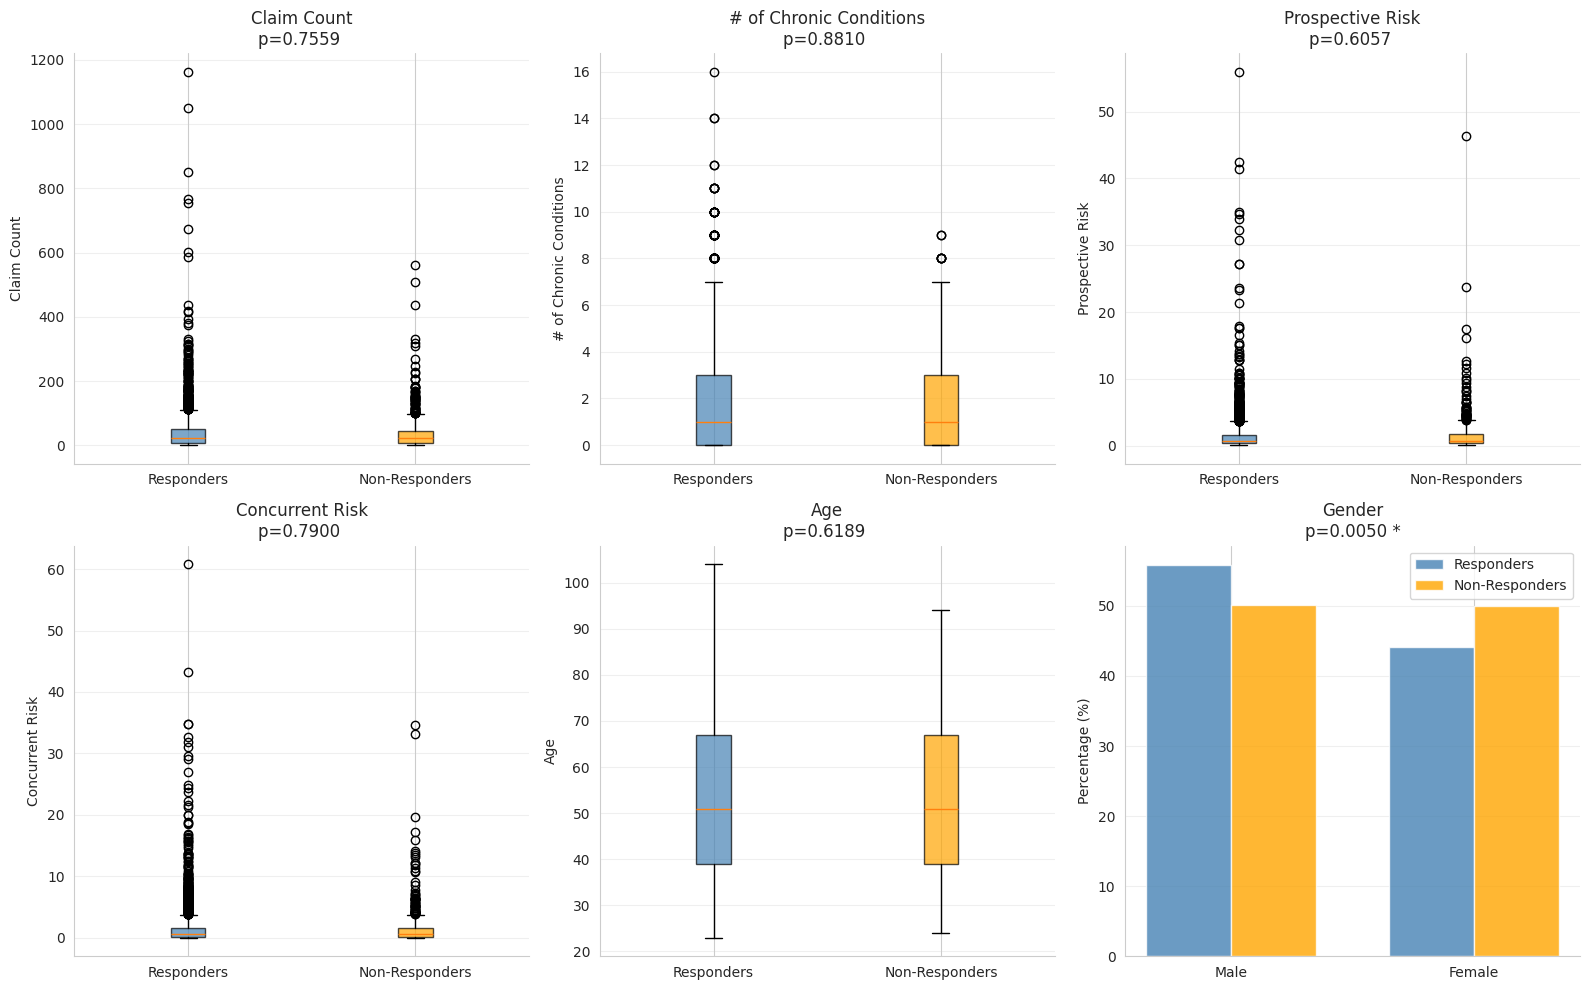

In [51]:
from scipy.stats import ttest_ind, chi2_contingency

metrics = ['Claim Count', '# of Chronic Conditions', 'Prospective Risk', 'Concurrent Risk', 'Age']

print("=" * 80)
print("RESPONDERS vs NON-RESPONDERS: OVERALL COMPARISON")
print("=" * 80)

# Continuous metrics - t-test
for metric in metrics:
    responders = merged_df[merged_df['Responded'] == 1][metric].dropna()
    non_responders = merged_df[merged_df['Responded'] == 0][metric].dropna()

    t_stat, p_val = ttest_ind(responders, non_responders)

    sig = "***" if p_val < 0.05 else ""
    print(f"\n{metric}:")
    print(f"  Responders    - Mean: {responders.mean():>10.2f} | Median: {responders.median():>10.2f} | N={len(responders)}")
    print(f"  Non-Responders- Mean: {non_responders.mean():>10.2f} | Median: {non_responders.median():>10.2f} | N={len(non_responders)}")
    print(f"  P-value: {p_val:.4f} {sig}")

# Gender - chi-square test
print(f"\nGender:")
resp_gender = merged_df[merged_df['Responded'] == 1]['Member Gender'].value_counts()
non_resp_gender = merged_df[merged_df['Responded'] == 0]['Member Gender'].value_counts()

contingency = pd.crosstab(
    pd.Series(['Responder']*merged_df[merged_df['Responded'] == 1].shape[0] +
              ['Non-Responder']*merged_df[merged_df['Responded'] == 0].shape[0]),
    pd.Series(list(merged_df[merged_df['Responded'] == 1]['Member Gender']) +
              list(merged_df[merged_df['Responded'] == 0]['Member Gender']))
)
chi2, p_val, dof, expected = chi2_contingency(contingency)

sig = "***" if p_val < 0.05 else ""
print(f"  Responders    - M: {(resp_gender.get('M', 0) / resp_gender.sum() * 100):.1f}% | F: {(resp_gender.get('F', 0) / resp_gender.sum() * 100):.1f}%")
print(f"  Non-Responders- M: {(non_resp_gender.get('M', 0) / non_resp_gender.sum() * 100):.1f}% | F: {(non_resp_gender.get('F', 0) / non_resp_gender.sum() * 100):.1f}%")
print(f"  P-value: {p_val:.4f} {sig}")

# Visualize
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    responders = merged_df[merged_df['Responded'] == 1][metric].dropna()
    non_responders = merged_df[merged_df['Responded'] == 0][metric].dropna()

    t_stat, p_val = ttest_ind(responders, non_responders)
    sig_marker = '*' if p_val < 0.05 else ''

    data_to_plot = [responders, non_responders]
    bp = ax.boxplot(data_to_plot, labels=['Responders', 'Non-Responders'], patch_artist=True)

    for patch, color in zip(bp['boxes'], ['steelblue', 'orange']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_ylabel(metric)
    ax.set_title(f'{metric}\np={p_val:.4f} {sig_marker}')
    ax.grid(axis='y', alpha=0.3)

# Gender bar chart
ax = axes[5]
categories = ['Male', 'Female']
responders_gender = [(resp_gender.get('M', 0) / resp_gender.sum() * 100),
                     (resp_gender.get('F', 0) / resp_gender.sum() * 100)]
non_responders_gender = [(non_resp_gender.get('M', 0) / non_resp_gender.sum() * 100),
                         (non_resp_gender.get('F', 0) / non_resp_gender.sum() * 100)]

x = np.arange(len(categories))
width = 0.35

ax.bar(x - width/2, responders_gender, width, label='Responders', alpha=0.8, color='steelblue')
ax.bar(x + width/2, non_responders_gender, width, label='Non-Responders', alpha=0.8, color='orange')

chi2, p_val, dof, expected = chi2_contingency(contingency)
sig_marker = '*' if p_val < 0.05 else ''

ax.set_ylabel('Percentage (%)')
ax.set_title(f'Gender\np={p_val:.4f} {sig_marker}')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
ax.grid(axis='y', alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()

**2. Text Analysis**

**Text pre-processing and sentiment analysis**

In [52]:
#text cleaning function
def clean_text(text, remove_stopwords=False):
    """Clean and normalize text"""
    import re

    #expand contractions
    contractions_dict = {
        "ain't": "am not", "aren't": "are not", "can't": "cannot", "'cause": "because",
        "could've": "could have", "couldn't": "could not", "didn't": "did not",
        "doesn't": "does not", "don't": "do not", "hadn't": "had not",
        "hasn't": "has not", "haven't": "have not", "he'd": "he would",
        "he'll": "he will", "he's": "he is", "i'd": "i would",
        "i'll": "i will", "i'm": "i am", "i've": "i have",
        "isn't": "is not", "it'd": "it would", "it'll": "it will",
        "it's": "it is", "let's": "let us", "shouldn't": "should not",
        "that's": "that is", "there's": "there is", "they'd": "they would",
        "they'll": "they will", "they're": "they are", "they've": "they have",
        "wasn't": "was not", "we'd": "we would", "we'll": "we will",
        "we're": "we are", "we've": "we have", "weren't": "were not",
        "what's": "what is", "won't": "will not", "wouldn't": "would not",
        "you'd": "you would", "you'll": "you will", "you're": "you are",
        "you've": "you have"
    }

    text = text.lower()
    for contraction, expansion in contractions_dict.items():
        text = text.replace(contraction, expansion)

    #remove special characters
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

#apply cleaning
merged_df['Text_Cleaned'] = merged_df['Patient Survey Response'].fillna('').apply(clean_text)

print("\nText Cleaning Examples:")
for i in range(3):
    original = merged_df[merged_df['Patient Survey Response'].notna()].iloc[i]['Patient Survey Response']
    cleaned = merged_df[merged_df['Patient Survey Response'].notna()].iloc[i]['Text_Cleaned']
    print(f"\n  Original: {original}")
    print(f"  Cleaned:  {cleaned}")


Text Cleaning Examples:

  Original: I don't feel like my doctor listens to my concerns at all.
  Cleaned:  i do not feel like my doctor listens to my concerns at all

  Original: My provider is knowledgeable and compassionate. Highly recommend.
  Cleaned:  my provider is knowledgeable and compassionate highly recommend

  Original: My provider is knowledgeable and compassionate. Highly recommend.
  Cleaned:  my provider is knowledgeable and compassionate highly recommend


In [53]:
#text length check
responses = merged_df[merged_df['Patient Survey Response'].notna()]

char_lengths = responses['Text_Cleaned'].str.len()
word_lengths = responses['Text_Cleaned'].str.split().str.len()

print("\nCharacter Length:")
print(f"  Mean: {char_lengths.mean():.1f}")
print(f"  Median: {char_lengths.median():.1f}")
print(f"  Min: {char_lengths.min():.1f}")
print(f"  Max: {char_lengths.max():.1f}")

print("\nWord Count:")
print(f"  Mean: {word_lengths.mean():.1f}")
print(f"  Median: {word_lengths.median():.1f}")
print(f"  Min: {word_lengths.min():.1f}")
print(f"  Max: {word_lengths.max():.1f}")


Character Length:
  Mean: 65.6
  Median: 62.0
  Min: 52.0
  Max: 135.0

Word Count:
  Mean: 11.3
  Median: 11.0
  Min: 8.0
  Max: 24.0


In [54]:

# Calculate sentiment
sentiments = merged_df[merged_df['Patient Survey Response'].notna()]['Text_Cleaned'].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

# Categorize
def categorize_sentiment(score):
    if score > 0.1:
        return 'Positive'
    elif score < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

sentiment_categories = sentiments.apply(categorize_sentiment)

print("\nSentiment Statistics:")
print(f"  Mean Polarity: {sentiments.mean():.3f}")
print(f"  Median: {sentiments.median():.3f}")
print(f"  Std Dev: {sentiments.std():.3f}")
print(f"  Min: {sentiments.min():.3f}")
print(f"  Max: {sentiments.max():.3f}")

print("\nSentiment Distribution:")
print(sentiment_categories.value_counts())
print("\nPercentages:")
print((sentiment_categories.value_counts() / len(sentiments) * 100).round(2))

# Save to dataframe
merged_df['Sentiment_Polarity'] = sentiments
merged_df['Sentiment_Category'] = sentiment_categories


Sentiment Statistics:
  Mean Polarity: 0.194
  Median: 0.175
  Std Dev: 0.329
  Min: -0.430
  Max: 1.000

Sentiment Distribution:
Text_Cleaned
Positive    2220
Neutral     1197
Negative     649
Name: count, dtype: int64

Percentages:
Text_Cleaned
Positive    54.60
Neutral     29.44
Negative    15.96
Name: count, dtype: float64


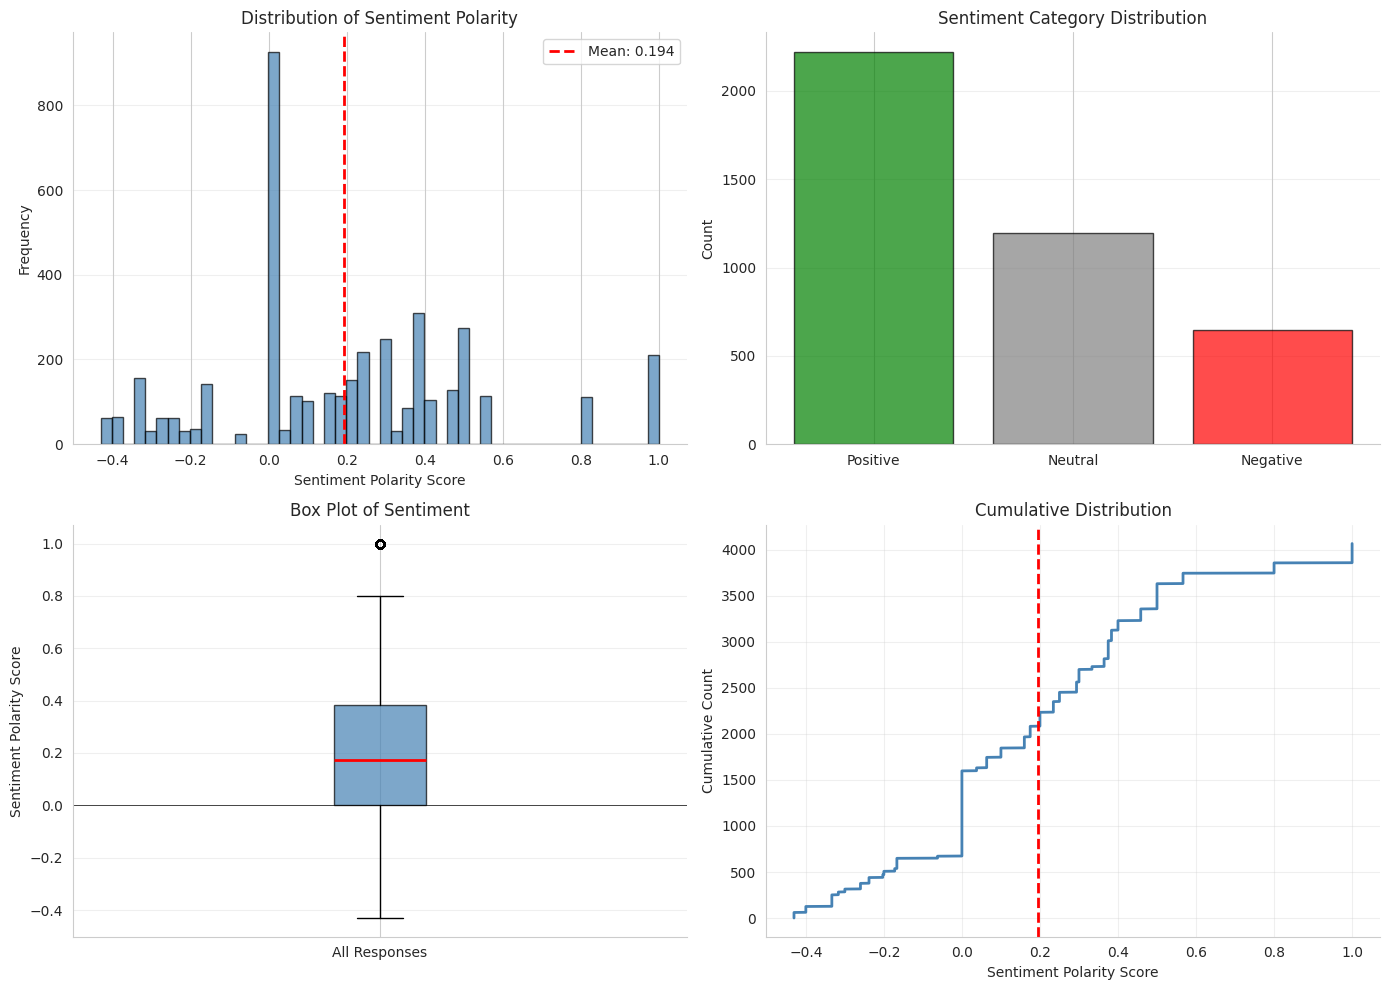

In [55]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram
axes[0, 0].hist(sentiments, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(sentiments.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {sentiments.mean():.3f}')
axes[0, 0].set_xlabel('Sentiment Polarity Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Sentiment Polarity')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Category bar chart
sentiment_counts = sentiment_categories.value_counts()
colors = ['green', 'gray', 'red']
axes[0, 1].bar(sentiment_counts.index, sentiment_counts.values, color=colors, alpha=0.7, edgecolor='black')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Sentiment Category Distribution')
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Box plot
bp = axes[1, 0].boxplot([sentiments], vert=True, patch_artist=True,
                         boxprops=dict(facecolor='steelblue', alpha=0.7),
                         medianprops=dict(color='red', linewidth=2))
axes[1, 0].set_ylabel('Sentiment Polarity Score')
axes[1, 0].set_title('Box Plot of Sentiment')
axes[1, 0].set_xticklabels(['All Responses'])
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].axhline(0, color='black', linestyle='-', linewidth=0.5)

# 4. Cumulative
sorted_sentiments = sentiments.sort_values()
cumulative = range(1, len(sorted_sentiments) + 1)
axes[1, 1].plot(sorted_sentiments, cumulative, linewidth=2, color='steelblue')
axes[1, 1].set_xlabel('Sentiment Polarity Score')
axes[1, 1].set_ylabel('Cumulative Count')
axes[1, 1].set_title('Cumulative Distribution')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axvline(sentiments.mean(), color='red', linestyle='--', linewidth=2)

finalize_plot()

**Topic Modeling with BERTopic**

In [56]:
#fitting bertopic
texts = merged_df[merged_df['Patient Survey Response'].notna()]['Text_Cleaned'].tolist()

# Custom stopwords
custom_stopwords = ['my', 'and', 'is', 'the', 'it']

vectorizer_model = CountVectorizer(
    stop_words=custom_stopwords,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2)
)

#fit
topic_model = BERTopic(
    vectorizer_model=vectorizer_model,
    language="english",
    calculate_probabilities=True,
    nr_topics=5,
    min_topic_size=40,
    embedding_model='all-mpnet-base-v2'
)

topics, probs = topic_model.fit_transform(texts)

print(f"\nTopics found: {len(set(topics))}")
print("\nTopic Info:")
print(topic_model.get_topic_info())

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Topics found: 5

Topic Info:
   Topic  Count                                        Name  \
0     -1    119  -1_back pain_am_diabetes_managing diabetes   
1      0   3524                  0_are_feel_experience_more   
2      1    193                    1_get_never_up very_keep   
3      2    167                     2_visits_others_some_me   
4      3     63           3_communication_does_does not_not   

                                      Representation  \
0  [back pain, am, diabetes, managing diabetes, m...   
1  [are, feel, experience, more, this, am, not, u...   
2  [get, never, up very, keep, can, through, mixe...   
3  [visits, others, some, me, experience, between...   
4   [communication, does, does not, not, , , , , , ]   

                                 Representative_Docs  
0  [managing my diabetes and depression at the sa...  
1  [i feel like my concerns are taken seriously e...  
2  [i can never get through on the phone it rings...  
3  [average experience some visits

In [57]:
#top terms per topic
for topic in sorted(topic_model.get_topics().keys()):
    if topic != -1:
        terms = topic_model.get_topic(topic)
        print(f"\nTopic {topic}:")
        for term, weight in terms[:10]:
            print(f"  {term:25} {weight:.3f}")


Topic 0:
  are                       0.113
  feel                      0.104
  experience                0.100
  more                      0.093
  this                      0.083
  am                        0.083
  not                       0.080
  up                        0.080
  very                      0.078
  time                      0.068

Topic 1:
  get                       0.318
  never                     0.318
  up very                   0.289
  keep                      0.273
  can                       0.263
  through                   0.242
  mixed                     0.224
  medications               0.208
  every                     0.161
  up                        0.161

Topic 2:
  visits                    0.373
  others                    0.248
  some                      0.248
  me                        0.160
  experience                0.155
  between visits            0.155
  are                       0.140
  here                      0.124
  just            

In [58]:
#updated with topics
topic_assignment = pd.Series(topics, index=merged_df[merged_df['Patient Survey Response'].notna()].index)
merged_df['Topic'] = topic_assignment

#topic distribution
print(merged_df['Topic'].value_counts().sort_index())

Topic
-1.0     119
 0.0    3524
 1.0     193
 2.0     167
 3.0      63
Name: count, dtype: int64


**Topic Labelling with Claude**

In [59]:

api_key = userdata.get('ANTHROPIC_API_KEY')
client = anthropic.Anthropic(api_key=api_key)

In [60]:
#extract top terms
topic_terms = {}
for topic in sorted(topic_model.get_topics().keys()):
    if topic != -1:
        terms = topic_model.get_topic(topic)
        top_words = [word for word, weight in terms[:10]]
        topic_terms[topic] = top_words

print("\nCurrent topic terms:")
for topic, words in topic_terms.items():
    print(f"  Topic {topic}: {', '.join(words)}")


Current topic terms:
  Topic 0: are, feel, experience, more, this, am, not, up, very, time
  Topic 1: get, never, up very, keep, can, through, mixed, medications, every, up
  Topic 2: visits, others, some, me, experience, between visits, are, here, just, between
  Topic 3: communication, does, does not, not, , , , , , 


In [61]:
#generate labels
topic_labels = {}

for topic, words in topic_terms.items():
    prompt = f"""You are a healthcare market research analyst naming topics from patient survey responses about their provider experience.

Top words from Topic {topic}:
{', '.join(words)}

Provide TWO labels:
1. A brief 2-3 word MAIN LABEL (e.g., "Wait Times")
2. A DETAILED LABEL: one sentence describing what patients are discussing

Format your response EXACTLY like this:
Main Label: [2-3 words]
Detailed Label: [one sentence]

Do not include any other text."""

    message = client.messages.create(
        model="claude-3-haiku-20240307",
        max_tokens=100,
        messages=[{"role": "user", "content": prompt}]
    )

    response_text = message.content[0].text.strip()

    # Parse response
    main_label = ""
    detailed_label = ""

    for line in response_text.split('\n'):
        if line.startswith("Main Label:"):
            main_label = line.replace("Main Label:", "").strip()
        elif line.startswith("Detailed Label:"):
            detailed_label = line.replace("Detailed Label:", "").strip()

    topic_labels[topic] = {
        'main': main_label,
        'detailed': detailed_label
    }

    print(f"\n  Topic {topic}:")
    print(f"    Main: {main_label}")
    print(f"    Detail: {detailed_label}")


  Topic 0:
    Main: Patient Feelings
    Detail: Patients discuss their overall feelings and experiences with their healthcare provider.

  Topic 1:
    Main: Medication Management
    Detail: Patients express mixed experiences with getting their medications consistently and efficiently.

  Topic 2:
    Main: Visit Experience
    Detail: Patients are discussing their overall experience with their provider, including interactions during visits and in between visits.

  Topic 3:
    Main: Communication Quality
    Detail: Patients discussing the quality of communication with their healthcare providers, including what their providers do and do not do.


In [62]:
for topic in sorted(topic_labels.keys()):
    count = (merged_df['Topic'] == topic).sum()
    main = topic_labels[topic]['main']
    detail = topic_labels[topic]['detailed']

    print(f"\nTopic {topic}: {main}")
    print(f"  Detail: {detail}")
    print(f"  Responses: {count}")

#save labels to df
merged_df['Topic_Name'] = merged_df['Topic'].map(lambda x: topic_labels[x]['main'] if x in topic_labels else None)
merged_df['Topic_Detail'] = merged_df['Topic'].map(lambda x: topic_labels[x]['detailed'] if x in topic_labels else None)



Topic 0: Patient Feelings
  Detail: Patients discuss their overall feelings and experiences with their healthcare provider.
  Responses: 3524

Topic 1: Medication Management
  Detail: Patients express mixed experiences with getting their medications consistently and efficiently.
  Responses: 193

Topic 2: Visit Experience
  Detail: Patients are discussing their overall experience with their provider, including interactions during visits and in between visits.
  Responses: 167

Topic 3: Communication Quality
  Detail: Patients discussing the quality of communication with their healthcare providers, including what their providers do and do not do.
  Responses: 63



UMAP VISUALIZATION OF TOPICS
Extracting embeddings...
Running UMAP (this may take a minute)...


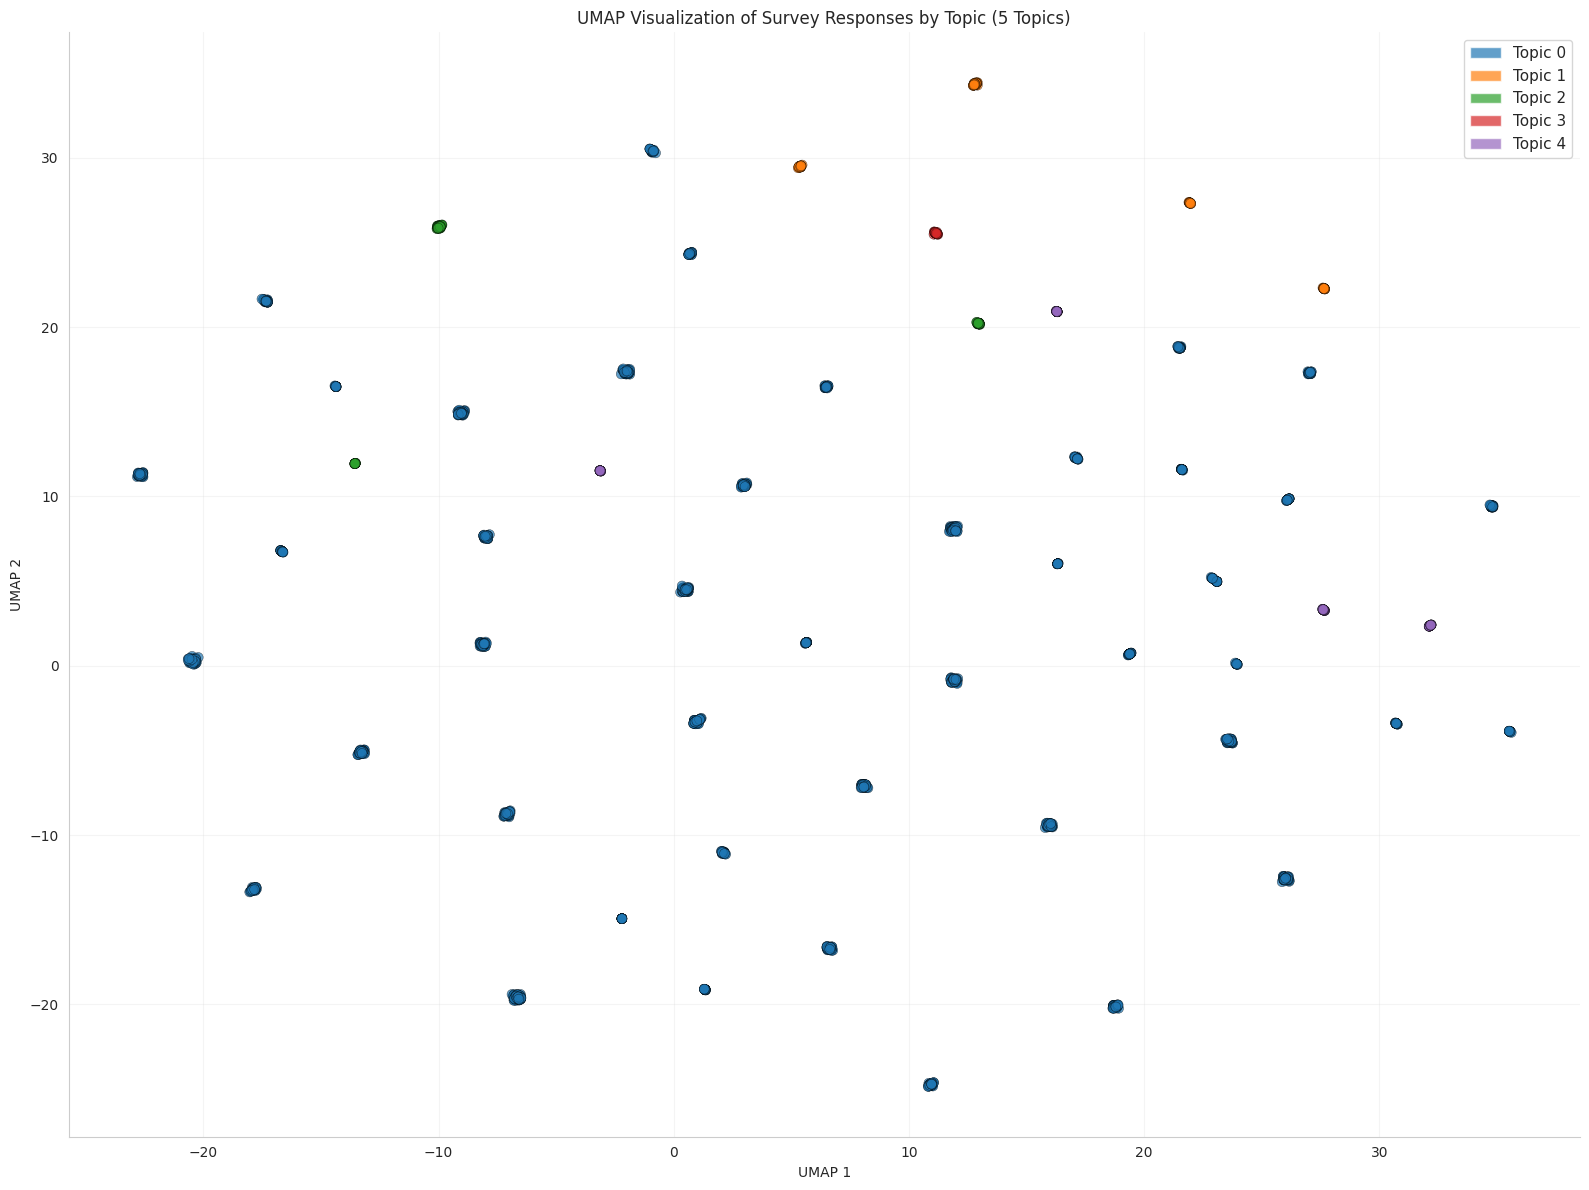

In [63]:
print_section("UMAP VISUALIZATION OF TOPICS")

# Get embeddings
print("Extracting embeddings...")
embeddings = topic_model._extract_embeddings(texts, method="document")

# UMAP
print("Running UMAP (this may take a minute)...")
umap_embeddings = UMAP(n_components=2, random_state=42, min_dist=0.1).fit_transform(embeddings)

# Create plot with circles
fig, ax = plt.subplots(figsize=(16, 12))

# Define distinct colors
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

scatter = ax.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1],
                     c=[colors[int(t)] for t in topics],
                     alpha=0.7, s=50, edgecolors='black', linewidth=0.3)

# Draw circles around topic clusters
from matplotlib.patches import Circle
for topic in range(5):
    topic_points = umap_embeddings[topics == topic]

    if len(topic_points) > 0:
        # Calculate centroid
        centroid = topic_points.mean(axis=0)

        # Calculate radius
        distances = np.linalg.norm(topic_points - centroid, axis=1)
        radius = distances.max() * 1.15 if len(distances) > 0 else 1

        # Draw circle
        circle = Circle(centroid, radius, fill=False, edgecolor=colors[topic],
                       linewidth=2.5, linestyle='--', alpha=0.7)
        ax.add_patch(circle)

        # Add topic label
        count = (merged_df['Topic'] == topic).sum()
        ax.text(centroid[0], centroid[1], f'Topic {topic}\n({count})',
               ha='center', va='center', fontsize=11, fontweight='bold',
               bbox=dict(boxstyle='round', facecolor=colors[topic], alpha=0.3))

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('UMAP Visualization of Survey Responses by Topic (5 Topics)')
ax.grid(True, alpha=0.2)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[i], label=f'Topic {i}', alpha=0.7) for i in range(5)]
ax.legend(handles=legend_elements, loc='upper right', fontsize=11)

finalize_plot()

UMAP displays semantic similarity to other survey responses.
- Topics overlap
- Orange (patient dissatisfaction) trends right
- Blue (patient experience) trends left center

Dissatisfaction uses distincly different language than experience.

In [64]:
import pyLDAvis
import pyLDAvis.lda_model

warnings.filterwarnings('ignore')

# Create document-term matrix
vectorizer = CountVectorizer(
    stop_words=['my', 'and', 'is', 'the', 'it'],
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2)
)

doc_term_matrix = vectorizer.fit_transform(texts)

# Fit LDA with 5 topics
print("Fitting LDA model...")
lda_model = LatentDirichletAllocation(
    n_components=5,
    random_state=42,
    max_iter=10,
    learning_method='online',
    n_jobs=-1
)

lda_output = lda_model.fit_transform(doc_term_matrix)

# Create pyLDAVis
print("Creating interactive visualization...")
vis = pyLDAvis.lda_model.prepare(lda_model, doc_term_matrix, vectorizer)

# Save and display
html_string = pyLDAvis.prepared_data_to_html(vis)
with open('ldavis.html', 'w') as f:
    f.write(html_string)

Fitting LDA model...
Creating interactive visualization...


How to interpret:
  - Left: Topic circles (size = prevalence, distance = similarity)
  - Right: Top terms per topic (adjust λ slider to balance frequency (1.0) and distinctiveness (0.0))
  - Red bars: Term frequency in selected topic
  - Blue bars: Term frequency overall

**Sentiment Analysis by Topic**

In [65]:
sentiment_by_topic = merged_df.groupby('Topic_Name')['Sentiment_Polarity'].agg([
    'count', 'mean', 'median', 'std'
]).round(3)

print("\nSentiment Statistics by Topic:")
print(sentiment_by_topic)

# Category breakdown
print("\nSentiment Category Breakdown:")
for topic in merged_df['Topic_Name'].unique():
    if pd.notna(topic):
        topic_data = merged_df[merged_df['Topic_Name'] == topic]
        sentiment_counts = topic_data['Sentiment_Category'].value_counts()
        total = len(topic_data)

        print(f"\n{topic}:")
        for sentiment, count in sentiment_counts.items():
            pct = count / total * 100
            print(f"  {sentiment:10} {count:5} ({pct:5.1f}%)")


Sentiment Statistics by Topic:
                       count   mean  median    std
Topic_Name                                        
Communication Quality     63 -0.238  -0.238  0.000
Medication Management    193 -0.084   0.000  0.122
Patient Feelings        3524  0.225   0.234  0.331
Visit Experience         167  0.121   0.175  0.081

Sentiment Category Breakdown:

Patient Feelings:
  Positive    2038 ( 57.8%)
  Neutral     1014 ( 28.8%)
  Negative     472 ( 13.4%)

Communication Quality:
  Negative      63 (100.0%)

Medication Management:
  Neutral      131 ( 67.9%)
  Negative      62 ( 32.1%)

Visit Experience:
  Positive     115 ( 68.9%)
  Neutral       52 ( 31.1%)


- Dissatisfaction is nuanced
- Patient experience is generally positive
- Patients are mostly satisfied between visits
- Access is described neutrally (not positive or negative)




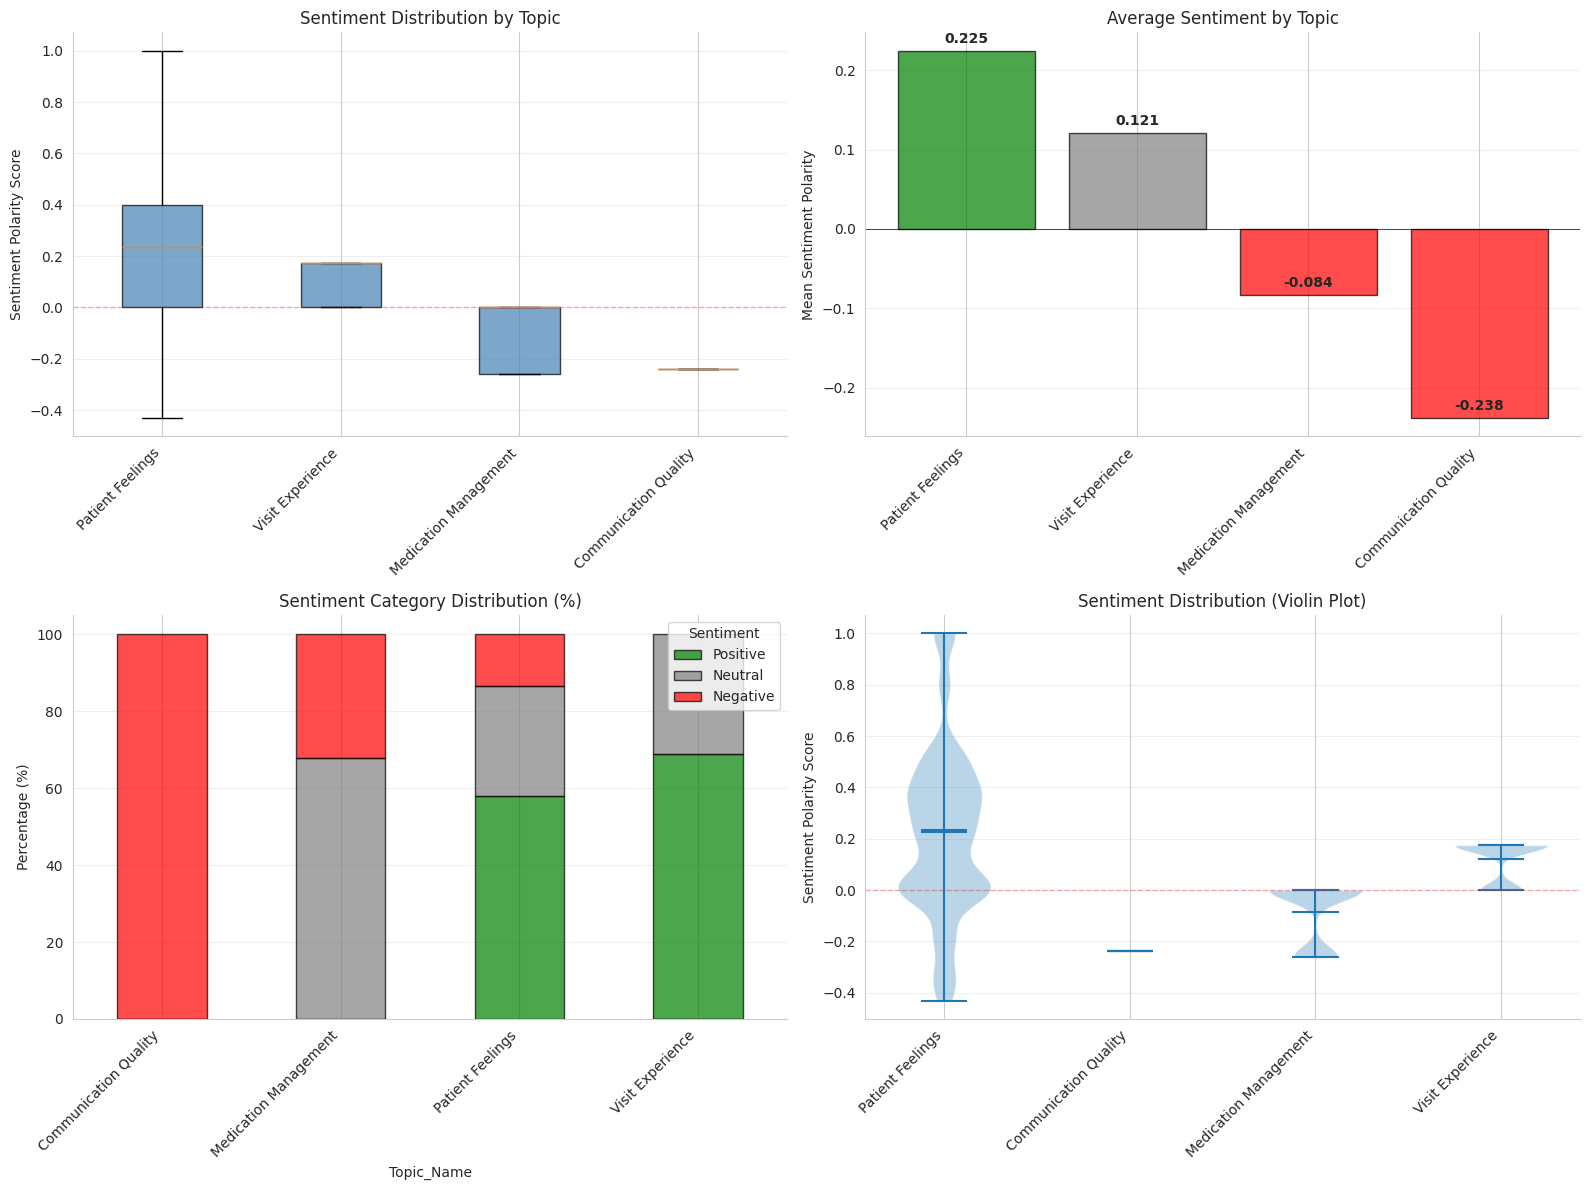

In [66]:
# Visualizations
mean_sentiment = merged_df.groupby('Topic_Name')['Sentiment_Polarity'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Box plot
topics_order = mean_sentiment.index
box_data = [merged_df[merged_df['Topic_Name'] == topic]['Sentiment_Polarity'].dropna()
            for topic in topics_order]

bp = axes[0, 0].boxplot(box_data, labels=topics_order, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)
axes[0, 0].set_ylabel('Sentiment Polarity Score')
axes[0, 0].set_title('Sentiment Distribution by Topic')
axes[0, 0].axhline(0, color='red', linestyle='--', alpha=0.3, linewidth=1)
axes[0, 0].grid(axis='y', alpha=0.3)
plt.setp(axes[0, 0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# 2. Mean sentiment bar chart
colors = ['green' if x > 0.15 else 'gray' if x > -0.05 else 'red' for x in mean_sentiment.values]
axes[0, 1].bar(range(len(mean_sentiment)), mean_sentiment.values, color=colors, alpha=0.7, edgecolor='black')
axes[0, 1].set_xticks(range(len(mean_sentiment)))
axes[0, 1].set_xticklabels(mean_sentiment.index, rotation=45, ha='right')
axes[0, 1].set_ylabel('Mean Sentiment Polarity')
axes[0, 1].set_title('Average Sentiment by Topic')
axes[0, 1].axhline(0, color='black', linestyle='-', linewidth=0.5)
axes[0, 1].grid(axis='y', alpha=0.3)

for i, v in enumerate(mean_sentiment.values):
    axes[0, 1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

# 3. Stacked bar chart
sentiment_by_topic_cat = pd.crosstab(merged_df['Topic_Name'],
                                      merged_df['Sentiment_Category'],
                                      normalize='index') * 100

sentiment_by_topic_cat[['Positive', 'Neutral', 'Negative']].plot(
    kind='bar', stacked=True, ax=axes[1, 0], color=['green', 'gray', 'red'],
    alpha=0.7, edgecolor='black'
)
axes[1, 0].set_ylabel('Percentage (%)')
axes[1, 0].set_title('Sentiment Category Distribution (%)')
axes[1, 0].legend(title='Sentiment', loc='upper right')
axes[1, 0].grid(axis='y', alpha=0.3)
plt.setp(axes[1, 0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# 4. Violin plot
violin_data = []
topic_labels_list = []
for topic in merged_df['Topic_Name'].unique():
    if pd.notna(topic):
        data = merged_df[merged_df['Topic_Name'] == topic]['Sentiment_Polarity'].dropna()
        violin_data.append(data)
        topic_labels_list.append(topic)

parts = axes[1, 1].violinplot(violin_data, positions=range(len(violin_data)),
                              showmeans=True, showmedians=True)
axes[1, 1].set_xticks(range(len(topic_labels_list)))
axes[1, 1].set_xticklabels(topic_labels_list, rotation=45, ha='right')
axes[1, 1].set_ylabel('Sentiment Polarity Score')
axes[1, 1].set_title('Sentiment Distribution (Violin Plot)')
axes[1, 1].axhline(0, color='red', linestyle='--', alpha=0.3, linewidth=1)
axes[1, 1].grid(axis='y', alpha=0.3)

finalize_plot()

* Patient experience is over 2x more positive than dissatisfaction


Claims & Costs Analysis By Topic

In [67]:
claims_by_topic = merged_df.groupby('Topic_Name').agg({
    'Total Paid Amount': ['count', 'mean', 'median', 'sum'],
    'Claim Count': ['mean', 'median'],
    'Sentiment_Polarity': 'mean'
}).round(2)

print("\nClaims & Costs by Topic:")
print(claims_by_topic)


Claims & Costs by Topic:
                      Total Paid Amount                                  \
                                  count      mean   median          sum   
Topic_Name                                                                
Communication Quality                52   6832.10  3707.11    355269.31   
Medication Management               167  10361.50  2455.03   1730370.08   
Patient Feelings                   2517   5112.42  1359.39  12867949.02   
Visit Experience                    122   4084.02  1556.11    498250.35   

                      Claim Count        Sentiment_Polarity  
                             mean median               mean  
Topic_Name                                                   
Communication Quality       52.56   37.0              -0.24  
Medication Management       58.44   30.0              -0.08  
Patient Feelings            38.08   21.0               0.22  
Visit Experience            35.56   21.0               0.12  


Access Issues
* Members mentioning problems with access to care cost more than those discussing their experience with a provider.

* Those with access issues, also have high claim volume

Patient Dissatisfaction
* Cost is higher than patient experience and high claim volume


In [68]:
print_section("STATISTICAL TEST: Topic Cost Differences")

topic_costs = [merged_df[merged_df['Topic_Name'] == topic]['Total Paid Amount'].dropna()
               for topic in merged_df['Topic_Name'].unique() if pd.notna(topic)]

h_stat, p_value = kruskal(*topic_costs)
print(f"\nKruskal-Wallis Test:")
print(f"  H-statistic: {h_stat:.4f}")
print(f"  P-value: {p_value:.4f}")
print(f"  Significant: {'YES ***' if p_value < 0.05 else 'NO'}")


STATISTICAL TEST: Topic Cost Differences

Kruskal-Wallis Test:
  H-statistic: 26.3461
  P-value: 0.0000
  Significant: YES ***


Topics do not have the same average cost.


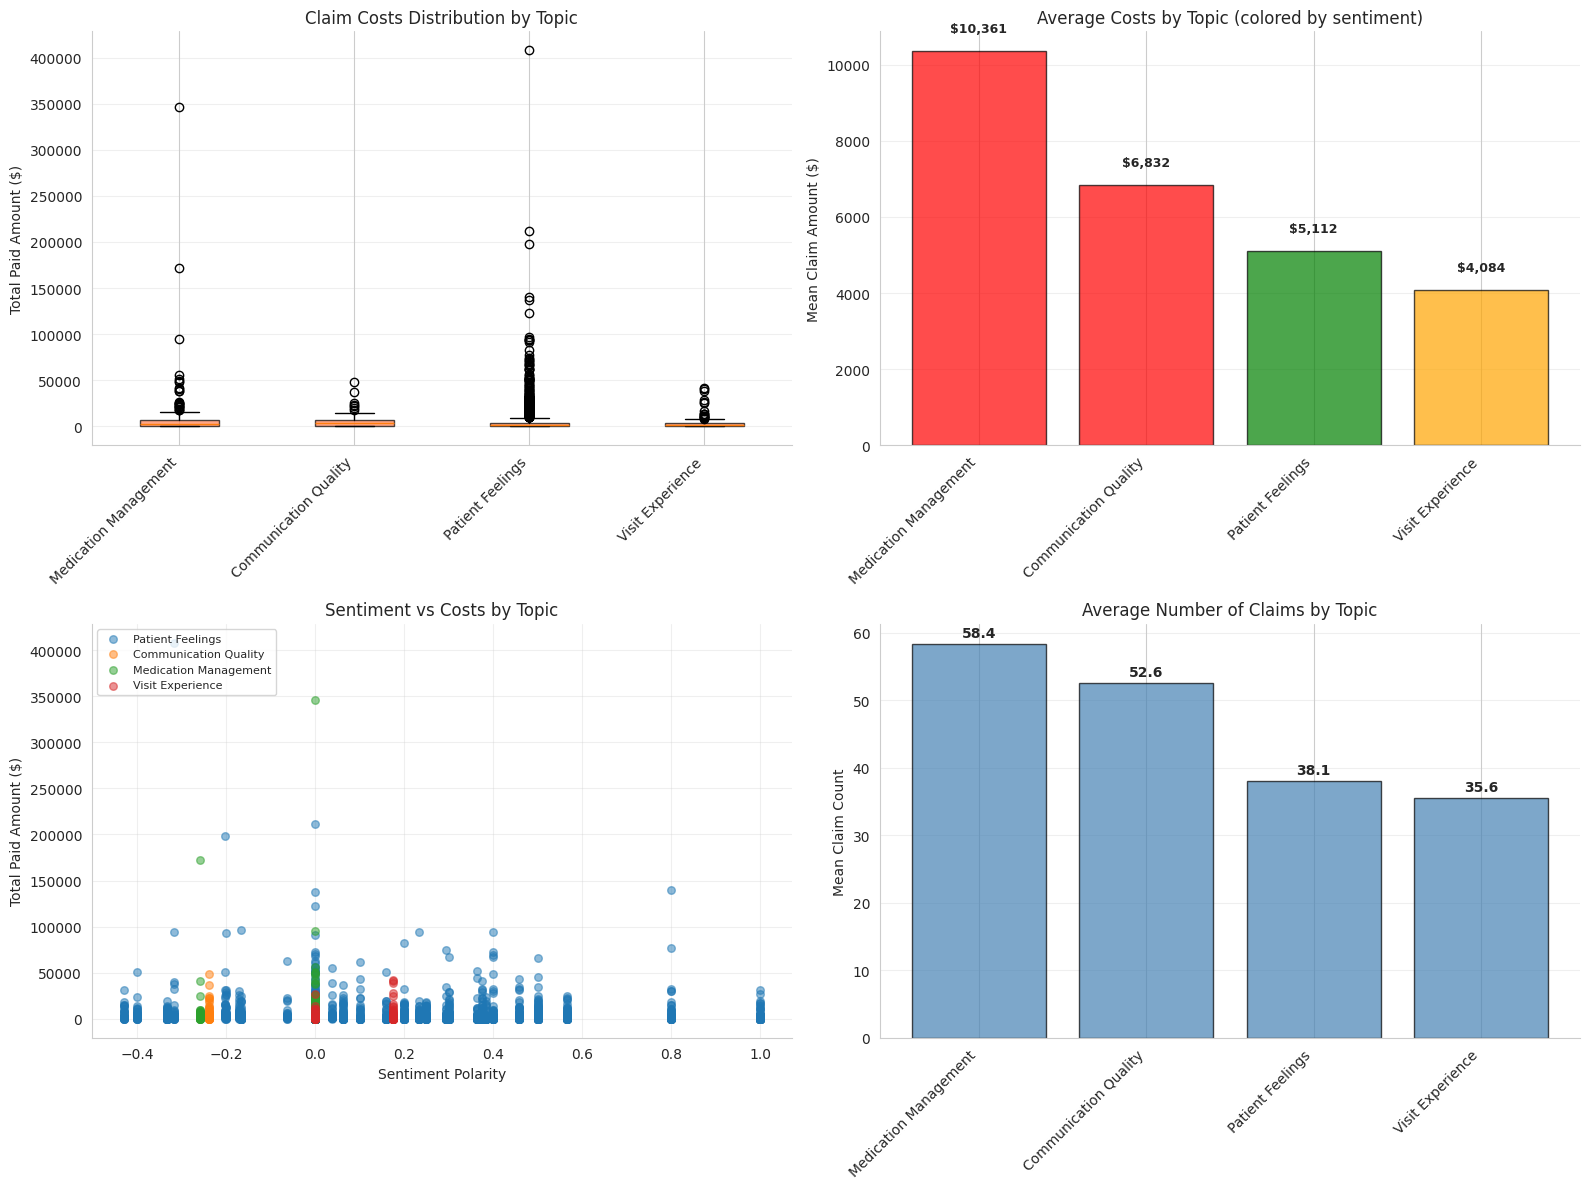

In [69]:
# Visualizations
mean_costs = merged_df.groupby('Topic_Name')['Total Paid Amount'].mean().sort_values(ascending=False)
mean_sentiment = merged_df.groupby('Topic_Name')['Sentiment_Polarity'].mean()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Box plot costs
topics_order = mean_costs.index
box_data = [merged_df[merged_df['Topic_Name'] == topic]['Total Paid Amount'].dropna()
            for topic in topics_order]

bp = axes[0, 0].boxplot(box_data, labels=topics_order, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('coral')
    patch.set_alpha(0.7)
axes[0, 0].set_ylabel('Total Paid Amount ($)')
axes[0, 0].set_title('Claim Costs Distribution by Topic')
axes[0, 0].grid(axis='y', alpha=0.3)
plt.setp(axes[0, 0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# 2. Mean costs bar chart (colored by sentiment)
colors = ['red' if mean_sentiment[topic] < 0 else 'orange' if mean_sentiment[topic] < 0.15 else 'green'
          for topic in mean_costs.index]

axes[0, 1].bar(range(len(mean_costs)), mean_costs.values, color=colors, alpha=0.7, edgecolor='black')
axes[0, 1].set_xticks(range(len(mean_costs)))
axes[0, 1].set_xticklabels(mean_costs.index, rotation=45, ha='right')
axes[0, 1].set_ylabel('Mean Claim Amount ($)')
axes[0, 1].set_title('Average Costs by Topic (colored by sentiment)')
axes[0, 1].grid(axis='y', alpha=0.3)

for i, v in enumerate(mean_costs.values):
    axes[0, 1].text(i, v + 500, f'${v:,.0f}', ha='center', fontsize=9, fontweight='bold')

# 3. Sentiment vs Cost scatter
for topic in merged_df['Topic_Name'].unique():
    if pd.notna(topic):
        data = merged_df[merged_df['Topic_Name'] == topic]
        axes[1, 0].scatter(data['Sentiment_Polarity'], data['Total Paid Amount'],
                          label=topic, alpha=0.5, s=30)

axes[1, 0].set_xlabel('Sentiment Polarity')
axes[1, 0].set_ylabel('Total Paid Amount ($)')
axes[1, 0].set_title('Sentiment vs Costs by Topic')
axes[1, 0].legend(fontsize=8, loc='upper left')
axes[1, 0].grid(True, alpha=0.3)

# 4. Claim count by topic
mean_claim_count = merged_df.groupby('Topic_Name')['Claim Count'].mean().sort_values(ascending=False)

axes[1, 1].bar(range(len(mean_claim_count)), mean_claim_count.values,
               color='steelblue', alpha=0.7, edgecolor='black')
axes[1, 1].set_xticks(range(len(mean_claim_count)))
axes[1, 1].set_xticklabels(mean_claim_count.index, rotation=45, ha='right')
axes[1, 1].set_ylabel('Mean Claim Count')
axes[1, 1].set_title('Average Number of Claims by Topic')
axes[1, 1].grid(axis='y', alpha=0.3)

for i, v in enumerate(mean_claim_count.values):
    axes[1, 1].text(i, v + 1, f'{v:.1f}', ha='center', fontweight='bold')

finalize_plot()

**Conditions by Topic Analysis**

In [70]:
#conditions prevelance by topic

condition_by_topic = pd.DataFrame()

for topic in merged_df['Topic_Name'].unique():
    if pd.notna(topic):
        topic_data = merged_df[merged_df['Topic_Name'] == topic]
        prevalence = {}

        for condition in conditions:
            prev = (topic_data[condition] == 1).sum() / len(topic_data) * 100
            prevalence[condition] = prev

        condition_by_topic[topic] = prevalence
#mean prevelance across all topics
condition_by_topic = condition_by_topic.iloc[condition_by_topic.mean(axis=1).argsort()[::-1]]

print("\nCondition Prevalence (%) by Topic:")
print(condition_by_topic.round(2))


Condition Prevalence (%) by Topic:
                             Patient Feelings  Communication Quality  \
Hypertension                            17.28                  25.40   
Lower Back Pain                         17.20                  30.16   
Depression                              15.04                  26.98   
Hyperlipidemia                          11.04                  23.81   
Diabetes                                 7.97                  17.46   
Chronic Pain                             8.12                  14.29   
Blood Disorders                          6.73                  12.70   
Asthma                                   4.77                   6.35   
Cancer                                   3.41                   4.76   
ADHD                                     2.19                   6.35   
Eating Disorders                         0.77                   0.00   
ESRD                                     0.20                   0.00   
Congestive Heart Failure    

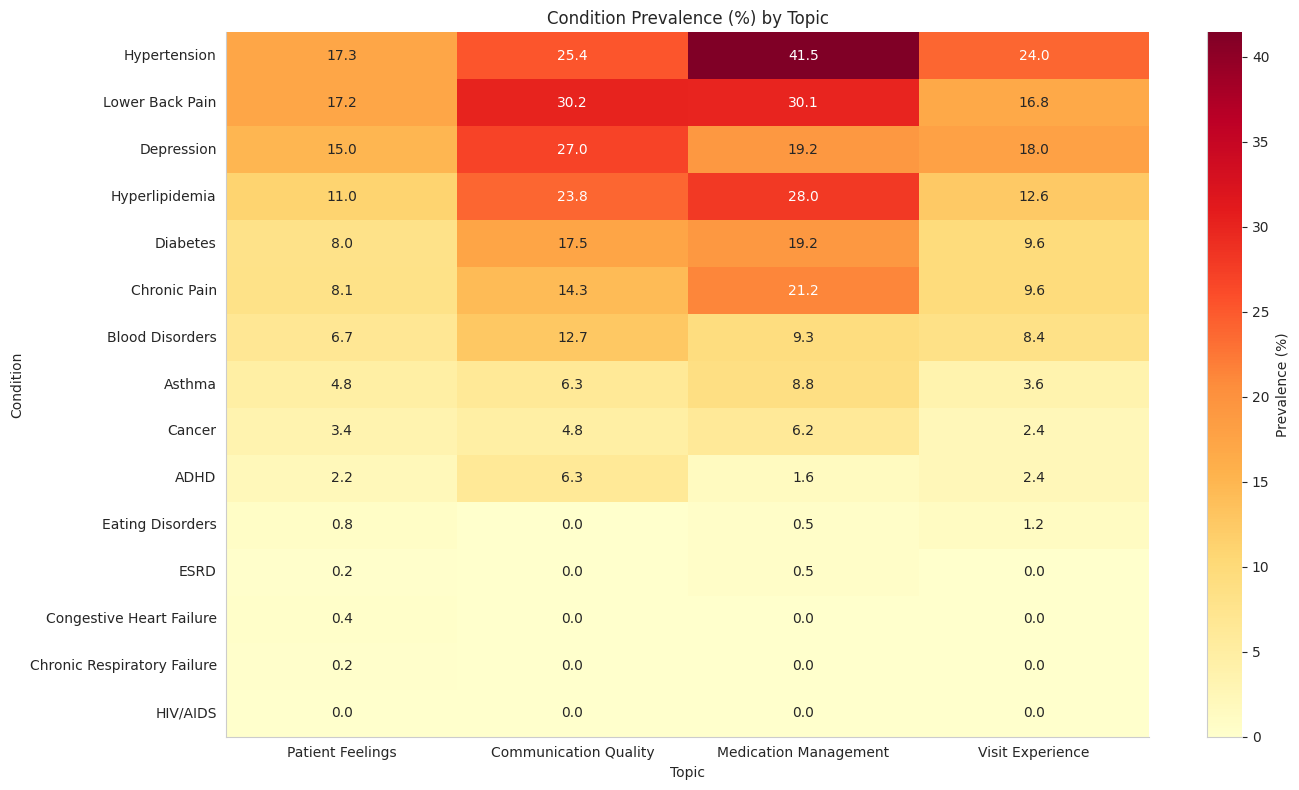

In [71]:
# Heatmap visualization
fig, ax = plt.subplots(figsize=(14, 8))

sns.heatmap(condition_by_topic, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Prevalence (%)'})

ax.set_title('Condition Prevalence (%) by Topic')
ax.set_xlabel('Topic')
ax.set_ylabel('Condition')

finalize_plot()

- Patient dissatisfaction: hypertension patient most unhappy
- Between visit experience: hypertension, lower back, depression patients concerned
- Access issues: difficulty with access across multiple chronic conditions

**Relationship Analysis: Cost, Topic, Sentiment, Claims, Conditions**

In [72]:
print_section("Cost vs topic vs claim count")

print("\nCorrelation of Claim Count with Cost (by Topic):")
for topic in merged_df['Topic_Name'].unique():
    if pd.notna(topic):
        topic_data = merged_df[merged_df['Topic_Name'] == topic].dropna(
            subset=['Claim Count', 'Total Paid Amount']
        )

        if len(topic_data) > 10:
            corr, p_value = spearmanr(topic_data['Claim Count'],
                                     topic_data['Total Paid Amount'])
            sig = "***" if p_value < 0.05 else ""
            print(f"  {topic:40} Correlation: {corr:>7.3f} | p={p_value:.4f} {sig}")

print("\nAverage Claim Count & Cost by Topic:")
claim_cost_topic = merged_df.groupby('Topic_Name').agg({
    'Claim Count': 'mean',
    'Total Paid Amount': 'mean'
}).round(2)
print(claim_cost_topic)


Cost vs topic vs claim count

Correlation of Claim Count with Cost (by Topic):
  Patient Feelings                         Correlation:   0.902 | p=0.0000 ***
  Communication Quality                    Correlation:   0.919 | p=0.0000 ***
  Medication Management                    Correlation:   0.903 | p=0.0000 ***
  Visit Experience                         Correlation:   0.901 | p=0.0000 ***

Average Claim Count & Cost by Topic:
                       Claim Count  Total Paid Amount
Topic_Name                                           
Communication Quality        52.56            6832.10
Medication Management        58.44           10361.50
Patient Feelings             38.08            5112.42
Visit Experience             35.56            4084.02


In [73]:
print_section("Conditions impact by sentiment")

print("\nAverage Sentiment by Condition:")
condition_sentiment = {}
for condition in conditions:
    with_cond = merged_df[merged_df[condition] == 1]['Sentiment_Polarity'].mean()
    without_cond = merged_df[merged_df[condition] == 0]['Sentiment_Polarity'].mean()
    diff = with_cond - without_cond

    condition_sentiment[condition] = {
        'With_Condition': with_cond,
        'Without_Condition': without_cond,
        'Difference': diff
    }

condition_sentiment_df = pd.DataFrame(condition_sentiment).T.sort_values('Difference')
print(condition_sentiment_df.round(3))

print("\nConditions Associated with NEGATIVE Sentiment:")
for cond, diff in condition_sentiment_df['Difference'].head(5).items():
    print(f"  {cond:30} {diff:+.3f}")

print("\nConditions Associated with POSITIVE Sentiment:")
for cond, diff in condition_sentiment_df['Difference'].tail(5).items():
    print(f"  {cond:30} {diff:+.3f}")


Conditions impact by sentiment

Average Sentiment by Condition:
                             With_Condition  Without_Condition  Difference
Chronic Respiratory Failure          -0.120              0.195      -0.315
ESRD                                 -0.009              0.195      -0.204
Diabetes                              0.068              0.207      -0.140
Congestive Heart Failure              0.059              0.195      -0.136
Hypertension                          0.097              0.218      -0.121
Hyperlipidemia                        0.094              0.209      -0.115
Cancer                                0.095              0.198      -0.103
Asthma                                0.098              0.200      -0.102
Chronic Pain                          0.103              0.204      -0.101
Depression                            0.125              0.208      -0.083
Lower Back Pain                       0.136              0.208      -0.071
Eating Disorders                   